In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

/Users/victor/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/victor/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Basic Functions

In [24]:
def load_and_prep_data(file_name):
    print(f"\n加载数据: {file_name} ...")
    df = pd.read_csv(file_name)
    
    # Convert timestamp and set as index
    df["Time_dt"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f", errors='coerce')
    df.set_index("Time_dt", inplace=True)
    
    # Create minute groups for later use
    df["Minute"] = df.index.floor("min")
    return df



def evaluate_and_plot(twap_buy, adaptive_buy, twap_sell, adaptive_sell, stock_name):
    """Compute improvement and generate summary table and plots"""
    
    buy_improvement = twap_buy - adaptive_buy
    sell_improvement = adaptive_sell - twap_sell
    twap_spread = twap_buy - twap_sell
    adaptive_spread = adaptive_buy - adaptive_sell

    # 1. Print performance summary
    summary_table = pd.DataFrame({
        "Metric": ["Average Buy Price", "Average Sell Price", "Average BUY-SELL Spread"],
        "TWAP": [twap_buy.mean(), twap_sell.mean(), twap_spread.mean()],
        "Adaptive": [adaptive_buy.mean(), adaptive_sell.mean(), adaptive_spread.mean()]
    })
    summary_table["Improvement"] = summary_table["TWAP"] - summary_table["Adaptive"]
    summary_table.loc[1, "Improvement"] = summary_table.loc[1, "Adaptive"] - summary_table.loc[1, "TWAP"]

    print(f"\n{'='*40}")
    print(f"[{stock_name}] Final Strategy Performance Summary")
    print(f"{'='*40}")
    print(summary_table.round(5))
    print(f"BUY Win Rate: {(buy_improvement > 0).mean():.2%}")
    print(f"SELL Win Rate: {(sell_improvement > 0).mean():.2%}")

    # 2. Generate core visualization (per-stock cumulative improvement)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].plot(range(1, len(buy_improvement)+1), buy_improvement.cumsum().values, color="purple")
    axes[0].set_title(f"[{stock_name}] Cumulative BUY Improvement")
    axes[0].set_xlabel("Minute")
    axes[0].grid(True)

    axes[1].plot(range(1, len(sell_improvement)+1), sell_improvement.cumsum().values, color="green")
    axes[1].set_title(f"[{stock_name}] Cumulative SELL Improvement")
    axes[1].set_xlabel("Minute")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

    # Key change: package core metrics for this stock into a dictionary and return
    return {
        "Ticker": stock_name,
        "BUY_Improvement": buy_improvement.mean(),
        "SELL_Improvement": sell_improvement.mean()
    }

# 【夯】策略1

In [198]:
def run_execution(train_read, side):
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 
    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)
    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum().values
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum().values
    train_read["VWOF"] = np.divide(net_flow_50, total_vol_50, out=np.zeros_like(net_flow_50), where=total_vol_50!=0)

    # B. 微观动量 (Micro-Momentum) - 确认价格趋势是否发生真实偏移
    train_read["MicroPrice"] = (
        (train_read["BidPrice_1"] * train_read["AskSize_1"] + train_read["AskPrice_1"] * train_read["BidSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"])
    )
    train_read["MidPrice"] = (train_read["BidPrice_1"] + train_read["AskPrice_1"]) / 2
    train_read["MicroMomentum"] = (train_read["MicroPrice"] - train_read["MidPrice"]).shift(1)


    # C. 价差与流动性过滤 (Spread Regime) - 控制交易成本
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]
    # 动态计算可以接受的价差上限（排除掉最宽的 20% 恶劣时刻）
    train_read["Spread_Limit"] = train_read["Spread"].rolling(300, min_periods=1).quantile(0.70)
    train_read.fillna(method='ffill', inplace=True)

    # ============================================================
    # 2️⃣ 分组数据
    # ============================================================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")
    minute_groups = train_read.groupby("Minute")


    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"
    
    twap_prices = []
    adaptive_prices = []
    
    for minute, group in minute_groups:
        twap_prices.append(group[exec_col].iloc[0])
        
        executed = False
        total_rows = len(group)
        
        for idx in range(total_rows):
            cur_price = group[exec_col].iloc[idx]
            cur_vwof = group["VWOF"].iloc[idx]
            cur_mom = group["MicroMomentum"].iloc[idx]
            cur_spread = group["Spread"].iloc[idx]
            cur_limit = group["Spread_Limit"].iloc[idx]
            
            #time_progress = idx / total_rows if total_rows > 0 else 1.0
            time_progress = (group.index[idx] - group.index[0]) / (group.index[-1] - group.index[0])
            
            # 第一重保护：交易成本过滤，不能在价差被恶意拉宽时做冤大头
            is_spread_safe = cur_spread <= cur_limit
            
            # 避开分钟初前 10% 的时间，因为这是全市场低智 TWAP 机器人互相踩踏引发点差扩大的高危期
            if time_progress > 0.03:
                if side == "BUY":
                    # 完美的入场条件 (需要三重确认)：
                    # 1. VWOF > 0.2: 看到多头真金白银在进场
                    # 2. MicroMom > 0: 且这股资金真真切切推高了微观价格(趋势得到验证)
                    # 3. 随着时间临近结束(>80%)，适当放低标准
                    if is_spread_safe and ((cur_vwof > 0.2 and cur_mom > 0) or (time_progress > 0.9 and cur_vwof > 0)):
                        adaptive_prices.append(cur_price)
                        executed = True
                        break
                        
                elif side == "SELL":
                    # 完美的逃顶条件：
                    # 1. VWOF < -0.2: 看到空头在疯狂砸盘或多头大面积撤单
                    # 2. MicroMom < 0: 且微观价格重心已经开始下移(下跌趋势被验证)
                    if is_spread_safe and ((cur_vwof < -0.2 and cur_mom < 0) or (time_progress > 0.8 and cur_vwof < 0)):
                        adaptive_prices.append(cur_price)
                        executed = True
                        break
                        
        # 兜底市价成交
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

===== GOOG =====


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


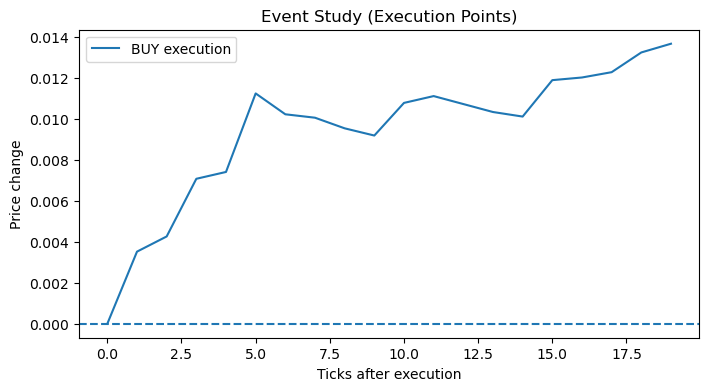

BUY execution count: 270
BUY avg return: 0.013666666666666027


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


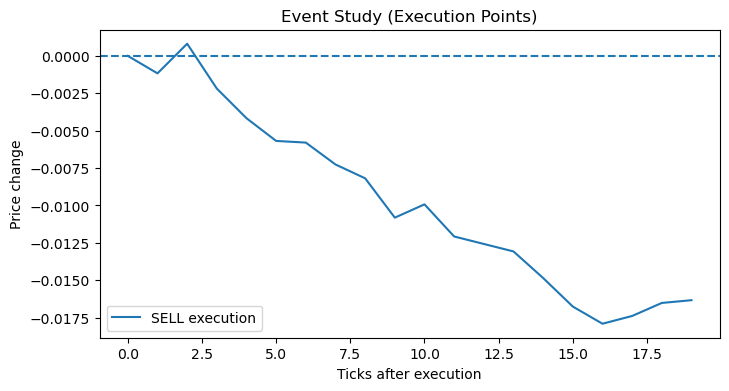

SELL execution count: 270
SELL avg return: -0.016333333333330688
===== AMZN =====


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


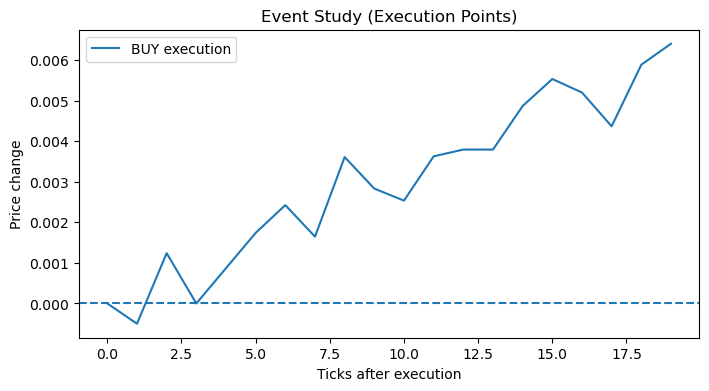

BUY execution count: 270
BUY avg return: 0.006407407407406632


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


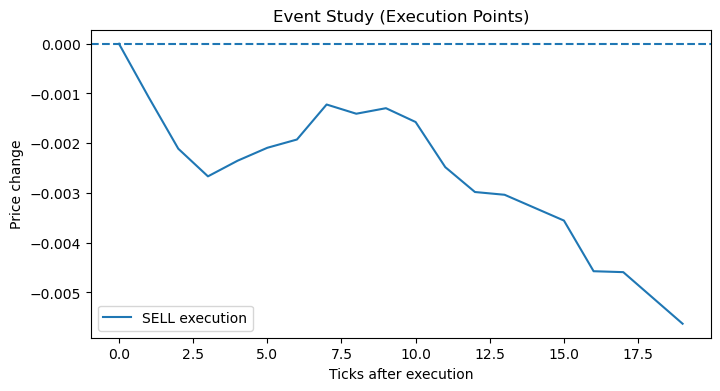

SELL execution count: 270
SELL avg return: -0.005629629629629563
===== MSFT =====


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


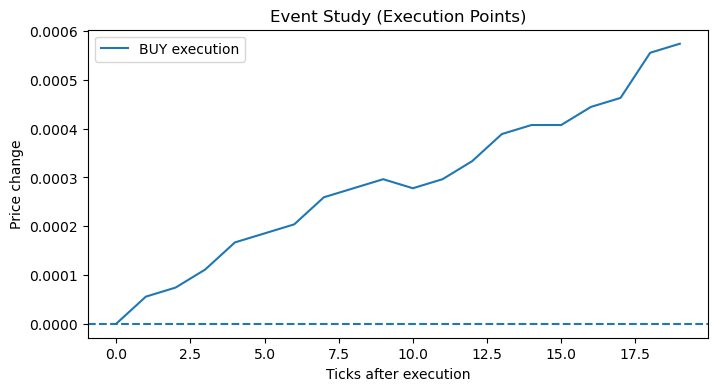

BUY execution count: 270
BUY avg return: 0.0005740740740740914


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


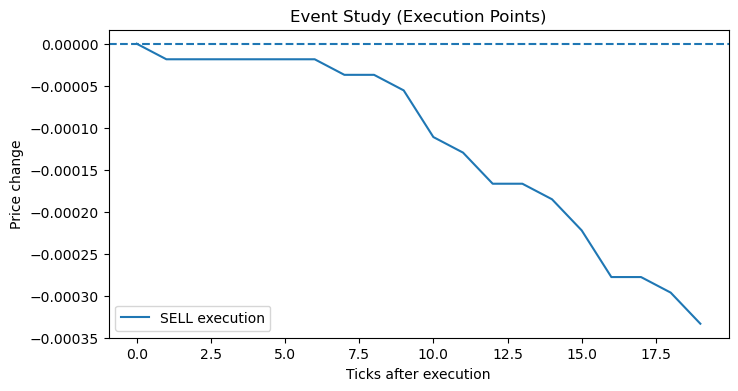

SELL execution count: 270
SELL avg return: -0.0003333333333332802
===== INTC =====


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


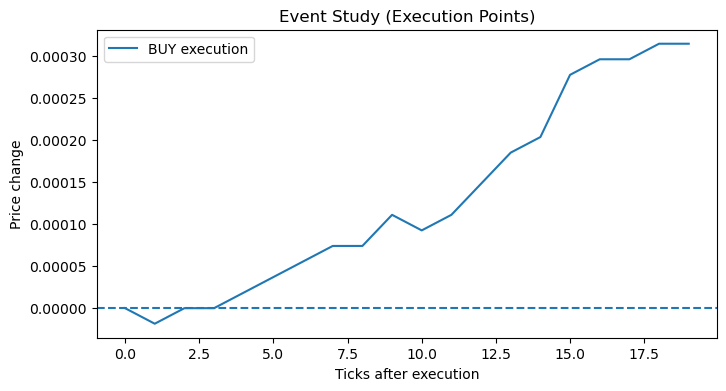

BUY execution count: 270
BUY avg return: 0.0003148148148147653


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/3585358200.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")


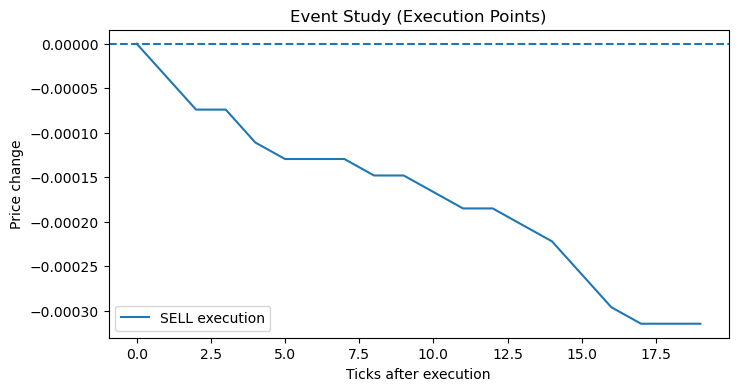

SELL execution count: 270
SELL avg return: -0.0003148148148147522


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def event_study_execution(train_read, side):

    df = train_read.copy()

    ############################################
    # 1️⃣ 特征（完全复刻你的策略）
    ############################################

    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values 

    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (df["PartialCancel_1=Yes_0=No"] | df["FullDelete_1=Yes_0=No"]).values
    is_exec = (df["VisibleExecution_1=Yes_0=No"] | df["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum()
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum()

    df["VWOF"] = net_flow_50 / (total_vol_50 + 1e-6)

    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    df["MicroPrice"] = (
        df["BidPrice_1"] * df["AskSize_1"] +
        df["AskPrice_1"] * df["BidSize_1"]
    ) / (df["BidSize_1"] + df["AskSize_1"] + 1e-6)

    df["MicroMomentum"] = df["MicroPrice"] - df["MidPrice"]

    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]

    df["Spread_Limit"] = (
        df["Spread"].rolling(300, min_periods=50).quantile(0.8).ffill()
    )

    ############################################
    # 2️⃣ 分钟分组（和策略一致）
    ############################################

    if "Minute" not in df.columns:
        df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")

    minute_groups = df.groupby("Minute")

    ############################################
    # 3️⃣ 找执行点（核心）
    ############################################

    execution_indices = []

    for minute, group in minute_groups:

        total_rows = len(group)
        executed = False

        for idx in range(total_rows):

            row = group.iloc[idx]

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            if time_progress <= 0.10:
                continue

            is_spread_safe = row["Spread"] <= row["Spread_Limit"]

            if side == "BUY":

                cond = (
                    is_spread_safe and
                    (
                        (row["VWOF"] > 0.2 and row["MicroMomentum"] > 0) or
                        (time_progress > 0.8 and row["VWOF"] > 0)
                    )
                )

            else:  # SELL

                cond = (
                    is_spread_safe and
                    (
                        (row["VWOF"] < -0.2 and row["MicroMomentum"] < 0) or
                        (time_progress > 0.8 and row["VWOF"] < 0)
                    )
                )

            if cond:
                execution_indices.append(row.name)
                executed = True
                break

        # fallback（也算执行点）
        if not executed:
            execution_indices.append(group.index[-1])

    ############################################
    # 4️⃣ Event Study
    ############################################

    horizon = 20
    mid = df["MidPrice"]

    paths = []

    for idx in execution_indices:

        loc = df.index.get_loc(idx)

        if loc + horizon < len(df):

            path = mid.iloc[loc:loc+horizon].values - mid.iloc[loc]
            paths.append(path)

    paths = np.array(paths)

    ############################################
    # 5️⃣ 画图
    ############################################

    mean_path = paths.mean(axis=0)

    plt.figure(figsize=(8,4))
    plt.plot(mean_path, label=f"{side} execution")
    plt.axhline(0, linestyle="--")
    plt.title("Event Study (Execution Points)")
    plt.xlabel("Ticks after execution")
    plt.ylabel("Price change")
    plt.legend()
    plt.show()

    ############################################
    # 6️⃣ 输出
    ############################################

    print(f"{side} execution count:", len(paths))
    print(f"{side} avg return:", mean_path[-1])


import pandas as pd

# 假设你已经有4个DataFrame：
# goog_df, amzn_df, msft_df, intc_df
# 或者你是从csv读入：

goog_df = pd.read_csv("GOOG_5levels_train.csv")
amzn_df = pd.read_csv("AMZN_5levels_train.csv")
msft_df = pd.read_csv("MSFT_5levels_train.csv")
intc_df = pd.read_csv("INTC_5levels_train.csv")

############################################
# 🚀 运行 Event Study
############################################

print("===== GOOG =====")
event_study_execution(goog_df, side="BUY")
event_study_execution(goog_df, side="SELL")

print("===== AMZN =====")
event_study_execution(amzn_df, side="BUY")
event_study_execution(amzn_df, side="SELL")

print("===== MSFT =====")
event_study_execution(msft_df, side="BUY")
event_study_execution(msft_df, side="SELL")

print("===== INTC =====")
event_study_execution(intc_df, side="BUY")
event_study_execution(intc_df, side="SELL")


===== GOOG =====
VWOF Quantile Result:
VWOF_bin
0   -0.008919
1   -0.005341
2    0.000933
3    0.001168
4    0.006406
Name: future_return, dtype: float64


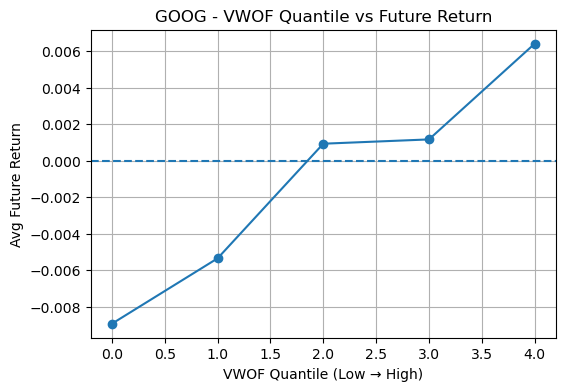


===== AMZN =====
VWOF Quantile Result:
VWOF_bin
0   -0.003004
1   -0.001771
2    0.000038
3    0.001131
4    0.003040
Name: future_return, dtype: float64


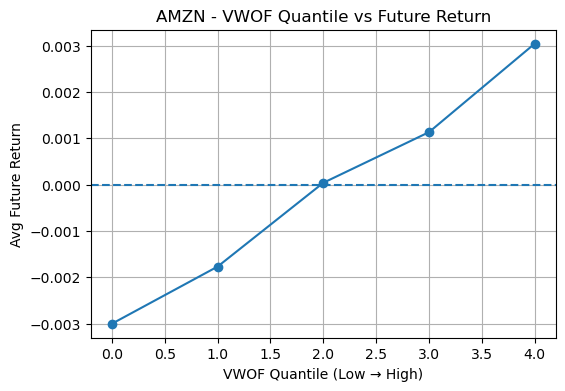


===== MSFT =====
VWOF Quantile Result:
VWOF_bin
0   -0.000241
1   -0.000117
2   -0.000013
3    0.000070
4    0.000241
Name: future_return, dtype: float64


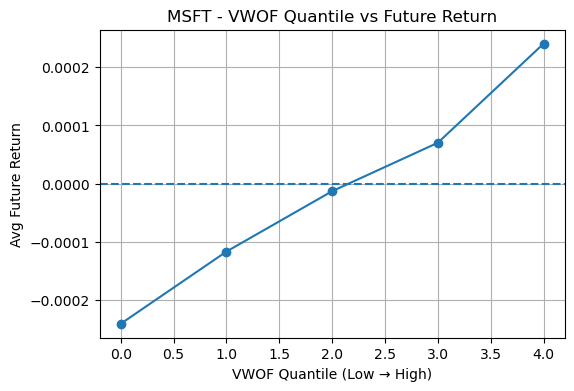


===== INTC =====
VWOF Quantile Result:
VWOF_bin
0   -0.000232
1   -0.000051
2    0.000002
3    0.000021
4    0.000180
Name: future_return, dtype: float64


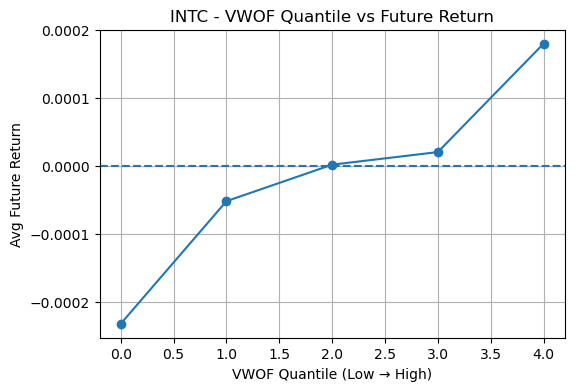

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

############################################
# 1️⃣ 读取数据（改成你的路径）
############################################

goog_df = pd.read_csv("GOOG_5levels_train.csv")
amzn_df = pd.read_csv("AMZN_5levels_train.csv")
msft_df = pd.read_csv("MSFT_5levels_train.csv")
intc_df = pd.read_csv("INTC_5levels_train.csv")

############################################
# 2️⃣ 定义一个统一分析流程（不是function调用，而是流程复用）
############################################

def run_quantile_analysis(df, name):

    df = df.copy()

    print(f"\n===== {name} =====")

    ############################################
    # 3️⃣ 构造 VWOF（和你策略一致）
    ############################################

    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values 

    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (df["PartialCancel_1=Yes_0=No"] | df["FullDelete_1=Yes_0=No"]).values
    is_exec = (df["VisibleExecution_1=Yes_0=No"] | df["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum()
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum()

    df["VWOF"] = net_flow_50 / (total_vol_50 + 1e-6)

    ############################################
    # 4️⃣ 构造 future return
    ############################################

    horizon = 10  # 你可以改成 5 / 20 做 robustness

    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    df["future_return"] = df["MidPrice"].shift(-horizon) - df["MidPrice"]

    df = df.dropna()

    ############################################
    # 5️⃣ 分位数分组
    ############################################

    df["VWOF_bin"] = pd.qcut(df["VWOF"], 5, labels=False)

    ############################################
    # 6️⃣ 统计
    ############################################

    result = df.groupby("VWOF_bin")["future_return"].mean()

    print("VWOF Quantile Result:")
    print(result)

    ############################################
    # 7️⃣ 画图
    ############################################

    plt.figure(figsize=(6,4))
    plt.plot(result.index, result.values, marker='o')
    plt.axhline(0, linestyle="--")
    plt.title(f"{name} - VWOF Quantile vs Future Return")
    plt.xlabel("VWOF Quantile (Low → High)")
    plt.ylabel("Avg Future Return")
    plt.grid(True)
    plt.show()


############################################
# 8️⃣ 运行所有股票
############################################

run_quantile_analysis(goog_df, "GOOG")
run_quantile_analysis(amzn_df, "AMZN")
run_quantile_analysis(msft_df, "MSFT")
run_quantile_analysis(intc_df, "INTC")

In [115]:
import numpy as np
import pandas as pd

############################################
# 1️⃣ 读取数据（自行修改路径）
############################################
goog_df = pd.read_csv("GOOG_5levels_train.csv")

############################################
# 2️⃣ 通用执行函数（支持开关因子）
############################################
def run_execution_ablation(train_read, side,
                          use_vwof=True,
                          use_mom=True,
                          use_spread=True):

    df = train_read.copy()

    ############################################
    # VWOF
    ############################################
    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values 

    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (df["PartialCancel_1=Yes_0=No"] | df["FullDelete_1=Yes_0=No"]).values
    is_exec = (df["VisibleExecution_1=Yes_0=No"] | df["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum()
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum()

    df["VWOF"] = net_flow_50 / (total_vol_50 + 1e-6)

    ############################################
    # Momentum
    ############################################
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    df["MicroPrice"] = (
        df["BidPrice_1"] * df["AskSize_1"] +
        df["AskPrice_1"] * df["BidSize_1"]
    ) / (df["BidSize_1"] + df["AskSize_1"] + 1e-6)

    df["MicroMomentum"] = df["MicroPrice"] - df["MidPrice"]

    ############################################
    # Spread
    ############################################
    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]
    df["Spread_Limit"] = df["Spread"].rolling(300, min_periods=50).quantile(0.8).ffill()

    ############################################
    # 分组
    ############################################
    if "Minute" not in df.columns:
        df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")

    minute_groups = df.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 执行逻辑
    ############################################
    for _, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            row = group.iloc[idx]
            time_progress = idx / total_rows

            if time_progress <= 0.1:
                continue

            conds = []

            if use_spread:
                conds.append(row["Spread"] <= row["Spread_Limit"])

            if side == "BUY":

                if use_vwof:
                    conds.append(row["VWOF"] > 0.2)

                if use_mom:
                    conds.append(row["MicroMomentum"] > 0)

                cond_main = all(conds) if conds else True

                cond_fallback = (
                    time_progress > 0.8 and
                    (row["VWOF"] > 0 if use_vwof else True)
                )

            else:  # SELL

                if use_vwof:
                    conds.append(row["VWOF"] < -0.2)

                if use_mom:
                    conds.append(row["MicroMomentum"] < 0)

                cond_main = all(conds) if conds else True

                cond_fallback = (
                    time_progress > 0.8 and
                    (row["VWOF"] < 0 if use_vwof else True)
                )

            if cond_main or cond_fallback:
                adaptive_prices.append(row[exec_col])
                executed = True
                break

        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

############################################
# 3️⃣ 评估函数
############################################
def evaluate_model(df, name, use_vwof, use_mom, use_spread):

    twap_buy, adaptive_buy = run_execution_ablation(
        df, "BUY", use_vwof, use_mom, use_spread)

    twap_sell, adaptive_sell = run_execution_ablation(
        df, "SELL", use_vwof, use_mom, use_spread)

    buy_improve = (twap_buy - adaptive_buy).mean()
    sell_improve = (adaptive_sell - twap_sell).mean()

    overall = buy_improve + sell_improve

    return {
        "Model": name,
        "BUY": buy_improve,
        "SELL": sell_improve,
        "Overall": overall
    }

############################################
# 4️⃣ 跑4组实验
############################################

results = []

# Full model
results.append(evaluate_model(goog_df, "Full",
                             True, True, True))

# No momentum
results.append(evaluate_model(goog_df, "No Momentum",
                             True, False, True))

# No VWOF
results.append(evaluate_model(goog_df, "No VWOF",
                             False, True, True))

# No Spread
results.append(evaluate_model(goog_df, "No Spread",
                             True, True, False))

############################################
# 5️⃣ 输出结果表
############################################

result_df = pd.DataFrame(results)
print(result_df)

/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/2543490112.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")
/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/2543490112.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")
/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_51129/2543490112.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")
/var/folders/31/b05

         Model       BUY      SELL   Overall
0         Full  0.059407  0.025852  0.085259
1  No Momentum  0.069852  0.026074  0.095926
2      No VWOF  0.006630  0.015407  0.022037
3    No Spread  0.057333  0.025222  0.082556


# 去掉momentum的策略

In [126]:
def run_execution(train_read, side):
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 
    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    ############################################
    # 1️⃣ VWOF（不变）
    ############################################
    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)
    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum().values
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum().values

    train_read["VWOF"] = np.divide(
        net_flow_50, total_vol_50,
        out=np.zeros_like(net_flow_50),
        where=total_vol_50 != 0
    )

    ############################################
    # 2️⃣ Spread（不变，但建议更稳一点）
    ############################################
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]
    train_read["Spread_Limit"] = (
        train_read["Spread"].rolling(300, min_periods=50).quantile(0.70)
    )
    train_read["Spread_Limit"].fillna(method='ffill', inplace=True)

    ############################################
    # 3️⃣ 分组（不变）
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 4️⃣ 执行逻辑（🔥只删 momentum）
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            cur_price = group[exec_col].iloc[idx]
            cur_vwof = group["VWOF"].iloc[idx]
            cur_spread = group["Spread"].iloc[idx]
            cur_limit = group["Spread_Limit"].iloc[idx]

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            is_spread_safe = cur_spread <= cur_limit

            if time_progress > 0.03:

                ####################################
                # BUY（去掉 momentum）
                ####################################
                if side == "BUY":

                    if is_spread_safe and (
                        (cur_vwof > 0.2) or
                        (time_progress > 0.8 and cur_vwof > 0)
                    ):
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                ####################################
                # SELL（去掉 momentum）
                ####################################
                elif side == "SELL":

                    if is_spread_safe and (
                        (cur_vwof < -0.2) or
                        (time_progress > 0.8 and cur_vwof < 0)
                    ):
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

        ####################################
        # fallback
        ####################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [118]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ VWOF
    ############################################
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 

    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)
    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum().values
    total_vol_50 = pd.Series(abs_flow).rolling(50, min_periods=1).sum().values

    train_read["VWOF"] = np.divide(
        net_flow_50, total_vol_50,
        out=np.zeros_like(net_flow_50),
        where=total_vol_50 != 0
    )

    ############################################
    # 2️⃣ Momentum（保留但用于条件判断）
    ############################################
    train_read["MicroPrice"] = (
        (train_read["BidPrice_1"] * train_read["AskSize_1"] + 
         train_read["AskPrice_1"] * train_read["BidSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"])
    )

    train_read["MidPrice"] = (
        train_read["BidPrice_1"] + train_read["AskPrice_1"]
    ) / 2

    train_read["MicroMomentum"] = (
        train_read["MicroPrice"] - train_read["MidPrice"]
    )

    ############################################
    # 3️⃣ Spread（修复版）
    ############################################
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]

    train_read["Spread_Limit"] = (
        train_read["Spread"].rolling(300, min_periods=50).quantile(0.80)
    )

    train_read["Spread_Limit"].fillna(method='ffill', inplace=True)

    ############################################
    # 4️⃣ 分组
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ Adaptive Execution
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            cur_price = group[exec_col].iloc[idx]
            cur_vwof = group["VWOF"].iloc[idx]
            cur_mom = group["MicroMomentum"].iloc[idx]
            cur_spread = group["Spread"].iloc[idx]
            cur_limit = group["Spread_Limit"].iloc[idx]

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            is_spread_safe = cur_spread <= cur_limit

            if time_progress <= 0.10:
                continue

            ########################################
            # 🔥 BUY
            ########################################
            if side == "BUY":

                if is_spread_safe:

                    # 🟢 强信号（GOOG型）
                    if cur_vwof > 0.3:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                    # 🟡 中信号（需要 momentum）
                    elif cur_vwof > 0.2 and cur_mom > 0:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                    # ⏱ fallback
                    elif time_progress > 0.8 and cur_vwof > 0:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

            ########################################
            # 🔥 SELL
            ########################################
            else:

                if is_spread_safe:

                    # 🟢 强信号
                    if cur_vwof < -0.3:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                    # 🟡 中信号
                    elif cur_vwof < -0.2 and cur_mom < 0:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                    # ⏱ fallback
                    elif time_progress > 0.8 and cur_vwof < 0:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

# 【一般】

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# Helper Function 1: 特征工程
# ============================================================
def calculate_features(df):
    # A. VWOF
    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values 
    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (df["PartialCancel_1=Yes_0=No"] | df["FullDelete_1=Yes_0=No"]).values
    is_exec = (df["VisibleExecution_1=Yes_0=No"] | df["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    net_flow = pd.Series(flow).rolling(50, min_periods=1).sum().values
    total_vol = pd.Series(np.abs(flow)).rolling(50, min_periods=1).sum().values
    df["VWOF"] = np.divide(net_flow, total_vol, out=np.zeros_like(net_flow), where=total_vol!=0)

    # B. Micro-Momentum & Imbalance
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2
    df["MicroPrice"] = (df["BidPrice_1"] * df["AskSize_1"] + df["AskPrice_1"] * df["BidSize_1"]) / (df["BidSize_1"] + df["AskSize_1"])
    df["MicroMom"] = df["MicroPrice"] - df["MidPrice"]
    df["Imbalance"] = (df["BidSize_1"] - df["AskSize_1"]) / (df["BidSize_1"] + df["AskSize_1"])
    
    # C. Spread Regime
    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]
    return df

# ============================================================
# Helper Function 2: 动态权重计算 (基于上一个窗口的因子贡献度)
# ============================================================
def get_dynamic_weights(last_group):
    if last_group is None or len(last_group) < 10:
        return {"vwof": 0.4, "mom": 0.3, "imb": 0.3} # 默认权重

    # 计算未来 N 个 tick 的价格变动作为目标变量
    lookahead = 10
    future_return = last_group["MidPrice"].shift(-lookahead) - last_group["MidPrice"]
    
    # 计算三个因子与未来回报的相关性 (取绝对值表示预测力)
    corr_vwof = abs(last_group["VWOF"].corr(future_return))
    corr_mom = abs(last_group["MicroMom"].corr(future_return))
    corr_imb = abs(last_group["Imbalance"].corr(future_return))
    
    # 归一化权重
    total_corr = corr_vwof + corr_mom + corr_imb
    if total_corr == 0 or np.isnan(total_corr):
        return {"vwof": 0.4, "mom": 0.3, "imb": 0.3}
        
    return {
        "vwof": corr_vwof / total_corr,
        "mom": corr_mom / total_corr,
        "imb": corr_imb / total_corr
    }

# ============================================================
# Main Execution Function
# ============================================================
def run_execution(train_read, side):
    # 1. 预计算特征
    train_read = calculate_features(train_read)
    train_read["Spread_Limit"] = train_read["Spread"].rolling(300, min_periods=1).quantile(0.80)
    
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")
    
    minute_groups = list(train_read.groupby("Minute"))
    
    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"
    twap_prices = []
    adaptive_prices = []
    
    last_group_data = None
    
    for i, (minute, group) in enumerate(minute_groups):
        twap_prices.append(group[exec_col].iloc[0])
        
        # 动态更新本分钟的权重
        # 逻辑：利用上一分钟的因子相关性来指导这一分钟的决策
        weights = get_dynamic_weights(last_group_data)
        last_group_data = group # 更新给下一轮使用
        
        executed = False
        total_rows = len(group)
        
        for idx in range(total_rows):
            vwof = group["VWOF"].iloc[idx]
            mom = group["MicroMom"].iloc[idx]
            imb = group["Imbalance"].iloc[idx]
            spread = group["Spread"].iloc[idx]
            limit = group["Spread_Limit"].iloc[idx]
            
            time_progress = idx / total_rows
            
            # 基础过滤：价差过大不成交
            if spread > limit: continue

            # 动态综合评分
            score = (weights["vwof"] * vwof + 
                     weights["mom"] * (1 if mom > 0 else -1) + 
                     weights["imb"] * imb)
            
            # 动态调整阈值 (随时间推进变得“急躁”)
            threshold = 0.5 * (1 - time_progress)

            if side == "BUY":
                # 买入：在分钟 10% 后寻找入场点，且 score 必须转正
                if time_progress > 0.10 and score > threshold:
                    adaptive_prices.append(group[exec_col].iloc[idx])
                    executed = True
                    break
                        
            elif side == "SELL":
                # 卖出：前 20% 时间非常敏感 (抢跑)，之后随门槛执行
                if time_progress < 0.20 and score < -0.45:
                    adaptive_prices.append(group[exec_col].iloc[idx])
                    executed = True
                    break
                elif time_progress >= 0.20 and (score < -threshold or spread < group["Spread"].iloc[0]):
                    adaptive_prices.append(group[exec_col].iloc[idx])
                    executed = True
                    break
        
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

# 【一般】

In [20]:
def run_execution(train_read, side):
    # ============================================================
    # 1️⃣ 特征预计算 (确保因子逻辑符合经济学直觉)
    # ============================================================
    # A. 订单流权重 (VWOF)
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 
    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    net_flow = pd.Series(flow).rolling(50, min_periods=1).sum().values
    total_vol = pd.Series(np.abs(flow)).rolling(50, min_periods=1).sum().values
    train_read["VWOF"] = np.divide(net_flow, total_vol, out=np.zeros_like(net_flow), where=total_vol!=0)

    # B. 微观动量 & 挂单失衡 (OBI)
    train_read["MicroPrice"] = (
        (train_read["BidPrice_1"] * train_read["AskSize_1"] + train_read["AskPrice_1"] * train_read["BidSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"])
    )
    train_read["MidPrice"] = (train_read["BidPrice_1"] + train_read["AskPrice_1"]) / 2
    train_read["MicroMom"] = train_read["MicroPrice"] - train_read["MidPrice"]
    train_read["Imbalance"] = (train_read["BidSize_1"] - train_read["AskSize_1"]) / (train_read["BidSize_1"] + train_read["AskSize_1"])

    # C. 价差控制
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]
    train_read["Spread_Limit"] = train_read["Spread"].rolling(300, min_periods=1).quantile(0.80)

    # ============================================================
    # 2️⃣ 执行逻辑 (多因子评分系统)
    # ============================================================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")
    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"
    twap_prices = []
    adaptive_prices = []
    
    for _, group in minute_groups:
        twap_prices.append(group[exec_col].iloc[0])
        
        executed = False
        total_rows = len(group)
        
        for idx in range(total_rows):
            # 提取因子标量
            cur_price = group[exec_col].iloc[idx]
            vwof = group["VWOF"].iloc[idx]
            mom = group["MicroMom"].iloc[idx]
            imb = group["Imbalance"].iloc[idx]
            spread = group["Spread"].iloc[idx]
            limit = group["Spread_Limit"].iloc[idx]
            
            time_progress = idx / total_rows
            
            # 价差基本保护：绝不在流动性枯竭时成交
            if spread > limit: continue

            # 核心策略：权重分配 (权重：VWOF 0.4, Momentum 0.3, Imbalance 0.3)
            # 计算综合得分 (-1 到 1)
            score = 0.4 * vwof + 0.3 * (1 if mom > 0 else -1) + 0.3 * imb
            
            # 入场门槛：随着时间推移，门槛逐渐从 0.5 降低到 0.1
            threshold = 0.5 * (1 - time_progress)

            if side == "BUY":
                # 买入逻辑：等待多头反攻或时间耗尽
                # 避开分钟初的拥挤期 (time > 10%)
                if time_progress > 0.10:
                    if score > threshold:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break
                        
            elif side == "SELL":
                # 卖出逻辑：极速抢跑，只要势头转负或时间过半立刻执行
                # 卖出得分看空头 (score 变负表示看跌)
                if time_progress < 0.20:
                    if score < -0.4: # 开局发现砸盘立刻跑
                        adaptive_prices.append(cur_price)
                        executed = True
                        break
                elif time_progress > 0.20:
                    if score < -threshold or spread <= group["Spread"].iloc[0]:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break
                        
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

# 【一般】

In [26]:
import numpy as np
import pandas as pd

# ==========================================
# Helper Functions
# ==========================================

def calculate_micro_features(df):
    """
    计算市场微观结构特征
    """
    df = df.copy()
    
    # 1. 订单流失衡 (Imbalance)
    df['Imbalance'] = (df['BidSize_1'] - df['AskSize_1']) / (df['BidSize_1'] + df['AskSize_1'])
    
    # 2. 微观价格与中价的漂移 (Micro-Price Drift)
    df['MicroPrice'] = (df['BidPrice_1'] * df['AskSize_1'] + df['AskPrice_1'] * df['BidSize_1']) / (df['BidSize_1'] + df['AskSize_1'])
    df['MicroDrift'] = (df['MicroPrice'] - df['MidPrice']) / (df['Spread'] + 1e-6)
    
    # 3. 订单簿斜率 (Slope - 探测薄盘和流动性真空区)
    ask_depth = df['AskSize_1'] + df['AskSize_2'] + df['AskSize_3'] + df['AskSize_4'] + df['AskSize_5']
    bid_depth = df['BidSize_1'] + df['BidSize_2'] + df['BidSize_3'] + df['BidSize_4'] + df['BidSize_5']
    
    df['Ask_Slope'] = (df['AskPrice_5'] - df['AskPrice_1']) / (ask_depth + 1e-6)
    df['Bid_Slope'] = (df['BidPrice_1'] - df['BidPrice_5']) / (bid_depth + 1e-6)
    
    return df


# ==========================================
# 主体执行逻辑 
# ==========================================

def run_execution(train_read, side):
    """
    自适应订单簿执行算法 (Regime-Adaptive Execution) - 修复高频重复索引问题
    """
    df = calculate_micro_features(train_read)
    
    if "Minute" not in df.columns:
        df["Minute"] = df.index.floor("min")
        
    twap_prices = []
    adaptive_prices = []
    
    grouped = df.groupby("Minute")
    
    for minute, min_df in grouped:
        if min_df.empty:
            continue
            
        # ----------------------------------
        # 1. TWAP 逻辑
        # ----------------------------------
        if side == "BUY":
            twap_prices.append(min_df['AskPrice_1'].iloc[0])
        else:
            twap_prices.append(min_df['BidPrice_1'].iloc[0])
            
        # ----------------------------------
        # 2. Adaptive 逻辑
        # ----------------------------------
        avg_spread = min_df['Spread'].mean()
        is_wide_spread = avg_spread > 0.05  
        
        if side == "BUY":
            if is_wide_spread:
                score = (min_df['Imbalance'] * 0.2) + (min_df['MicroDrift'] * 0.6) - (min_df['Ask_Slope'] * 0.2)
                threshold = 0.15 
            else:
                score = (min_df['Imbalance'] * 0.8) + (min_df['MicroDrift'] * 0.2)
                threshold = 0.5  
                
            triggers = score > threshold
            
            # 🌟 修复点：用布尔索引替代 .loc[idxmax()]
            if triggers.any():
                # 选出所有触发 True 的行，用 .iloc[0] 严格取第一个标量数值
                exec_price = min_df['AskPrice_1'][triggers].iloc[0]
            else:
                # 若无信号，本分钟最后一刻强制成交
                exec_price = min_df['AskPrice_1'].iloc[-1]
                
            adaptive_prices.append(exec_price)
            
        else: 
            # SELL 方向
            if is_wide_spread:
                score = (min_df['Imbalance'] * 0.2) + (min_df['MicroDrift'] * 0.6) + (min_df['Bid_Slope'] * 0.2)
                threshold = -0.1 
            else:
                score = (min_df['Imbalance'] * 0.8) + (min_df['MicroDrift'] * 0.2)
                threshold = -0.4
                
            triggers = score < threshold
            
            # 🌟 修复点：用布尔索引替代 .loc[idxmax()]
            if triggers.any():
                exec_price = min_df['BidPrice_1'][triggers].iloc[0]
            else:
                exec_price = min_df['BidPrice_1'].iloc[-1]
                
            adaptive_prices.append(exec_price)
            
    # 🌟 双重保险：明确指定 dtype=float，彻底杜绝类型报错
    return pd.Series(twap_prices, dtype=float), pd.Series(adaptive_prices, dtype=float)

In [48]:
def run_execution(train_read, side):
    """
    Enhanced Execution Strategy for INTC leveraging L2 Microstructure.
    
    Parameters:
    train_read (pd.DataFrame): Level 2 LOB data with columns: 
                               ['BidPrice_1..5', 'BidSize_1..5', 'AskPrice_1..5', 'AskSize_1..5', 
                                'HiddenExecution_1=Yes_0=No', 'FullDelete_1=Yes_0=No', etc.]
    side (int): 1 for Buy, -1 for Sell
    
    Returns:
    pd.Series: Execution signals or target weights
    """
    
    # 1. Micro-Price Calculation (Lead Indicator)
    # The Micro-price accounts for book pressure better than the Mid-Price
    train_read['MicroPrice'] = (train_read['BidPrice_1'] * train_read['AskSize_1'] + 
                                train_read['AskPrice_1'] * train_read['BidSize_1']) / \
                               (train_read['BidSize_1'] + train_read['AskSize_1'])
    
    train_read['Micro_Spread'] = train_read['MicroPrice'] - train_read['MidPrice']

    # 2. Multi-Level Order Flow Imbalance (OFI)
    # We apply weights to different levels (closer levels have higher weights)
    levels = range(1, 6)
    weights = [0.5, 0.2, 0.15, 0.1, 0.05]
    
    train_read['OFI'] = 0
    for i, w in zip(levels, weights):
        # Calculate change in size, adjusting for Full Deletions (Spoofing Filter)
        delta_bid = train_read[f'BidSize_{i}'].diff()
        delta_ask = train_read[f'AskSize_{i}'].diff()
        
        # If a full delete occurred, we assume it was a canceled 'spoof' order
        # and do not count it as a reduction in real buying/selling pressure.
        delta_bid = np.where(train_read[f'FullDelete_1=Yes_0=No'] == 1, 0, delta_bid)
        delta_ask = np.where(train_read[f'FullDelete_1=Yes_0=No'] == 1, 0, delta_ask)
        
        train_read['OFI'] += w * (delta_bid - delta_ask)

    # 3. Hidden Intensity Signal (HIS)
    # Detects institutional "Iceberg" activity by looking at HiddenExecution flags
    # We look for hidden executions in the direction of our trade
    train_read['Hidden_Signal'] = 0
    if side == 1: # Buying
        # Strong signal if hidden sellers are exhausted or hidden buyers appear
        train_read['Hidden_Signal'] = np.where((train_read['Direction_1=Buy_-1=Sell'] == 1) & 
                                               (train_read['HiddenExecution_1=Yes_0=No'] == 1), 
                                               train_read['Size'], 0)
    else: # Selling
        train_read['Hidden_Signal'] = np.where((train_read['Direction_1=Buy_-1=Sell'] == -1) & 
                                               (train_read['HiddenExecution_1=Yes_0=No'] == 1), 
                                               train_read['Size'], 0)

    # 4. Signal Integration
    # Normalizing signals using a rolling Z-score for consistency
    window = 50
    
    def z_score(x):
        return (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-9)

    combined_signal = (
        0.4 * z_score(train_read['OFI']) + 
        0.3 * z_score(train_read['Micro_Spread']) + 
        0.3 * z_score(train_read['Hidden_Signal'].rolling(window).sum())
    )

    # 5. Execution Decision
    # If side is 1 (Buy): Signal > Threshold means execute aggressively (Take)
    # If side is 1 (Buy): Signal < -Threshold means wait or execute passively (Post)
    threshold = 1.5
    execution_series = pd.Series(0, index=train_read.index)
    
    if side == 1:
        execution_series = np.where(combined_signal > threshold, 1, 0) # Buy Signal
    else:
        execution_series = np.where(combined_signal < -threshold, -1, 0) # Sell Signal
        
    return execution_series

# 【差】Order Imbalance

In [58]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ Order Imbalance（唯一信号）
    ############################################
    train_read["Imbalance"] = (
        (train_read["BidSize_1"] - train_read["AskSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"] + 1e-6)
    )

    ############################################
    # 2️⃣ 分钟分组
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 3️⃣ 执行逻辑（严格无 look-ahead）
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        # rolling reference（只用过去）
        running_min = None
        running_max = None

        for idx in range(total_rows):

            cur_imb = group["Imbalance"].iloc[idx]
            cur_price = group[exec_col].iloc[idx]

            # 更新历史极值（只到当前）
            if running_min is None:
                running_min = cur_imb
                running_max = cur_imb
            else:
                running_min = min(running_min, cur_imb)
                running_max = max(running_max, cur_imb)

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            ########################################
            # 决策（只用当前+过去信息）
            ########################################
            if time_progress > 0.1:  # 避开开盘噪音

                if side == "BUY":
                    # 当前是历史最低（卖压最强）
                    if cur_imb <= running_min:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                elif side == "SELL":
                    # 当前是历史最高（买压最强）
                    if cur_imb >= running_max:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

        ########################################
        # fallback（必须）
        ########################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    ############################################
    # 4️⃣ 返回（必须）
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

# 【可以】Spread Strategy

In [42]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ Spread（唯一信号）
    ############################################
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]

    ############################################
    # 2️⃣ 分钟分组
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 3️⃣ 执行逻辑（无 look-ahead）
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        running_min_spread = None

        for idx in range(total_rows):

            cur_spread = group["Spread"].iloc[idx]
            cur_price = group[exec_col].iloc[idx]

            # 更新历史最小 spread（只用过去）
            if running_min_spread is None:
                running_min_spread = cur_spread
            else:
                running_min_spread = min(running_min_spread, cur_spread)

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            ########################################
            # 决策
            ########################################
            if time_progress > 0.03:

                # 如果当前 spread 接近历史最优
                if cur_spread <= running_min_spread * 1.05:
                    adaptive_prices.append(cur_price)
                    executed = True
                    break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    ############################################
    # 4️⃣ 返回
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

## 策略变形

In [28]:
import numpy as np
import pandas as pd

def run_execution(train_read, side, stock_name=None):

    ############################################
    # 1️⃣ Spread
    ############################################
    train_read["Spread"] = train_read["AskPrice_1"] - train_read["BidPrice_1"]

    ############################################
    # 2️⃣ 分钟分组
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 3️⃣ threshold
    ############################################
    spread_series = train_read["Spread"]

    high_threshold = spread_series.quantile(0.7)
    low_threshold = spread_series.quantile(0.3)

    ############################################
    # 4️⃣ 执行
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            cur_spread = group["Spread"].iloc[idx]
            cur_price = group[exec_col].iloc[idx]

            time_progress = idx / total_rows if total_rows > 0 else 1.0

            ########################################
            # BUY
            ########################################
            if side == "BUY":

                if stock_name in ["GOOG", "MSFT"]:
                    if cur_spread >= high_threshold and time_progress > 0.1:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                elif stock_name == "AMZN":
                    if cur_spread <= low_threshold and time_progress > 0.1:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                else:  # INTC
                    if time_progress > 0.5:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

            ########################################
            # SELL（对称逻辑🔥）
            ########################################
            else:

                if stock_name in ["GOOG", "MSFT"]:
                    # spread 小才卖（trend continuation）
                    if cur_spread <= low_threshold and time_progress > 0.1:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                elif stock_name == "AMZN":
                    # spread 大才卖
                    if cur_spread >= high_threshold and time_progress > 0.1:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                else:  # INTC
                    if time_progress > 0.5:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    ############################################
    # 5️⃣ 返回
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

## spread vs future return



🚀 >>>>>>>>>> 开始回测: AMZN <<<<<<<<<<

加载数据: AMZN_5levels_train.csv ...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



🔍 Running Spread Validation for AMZN...


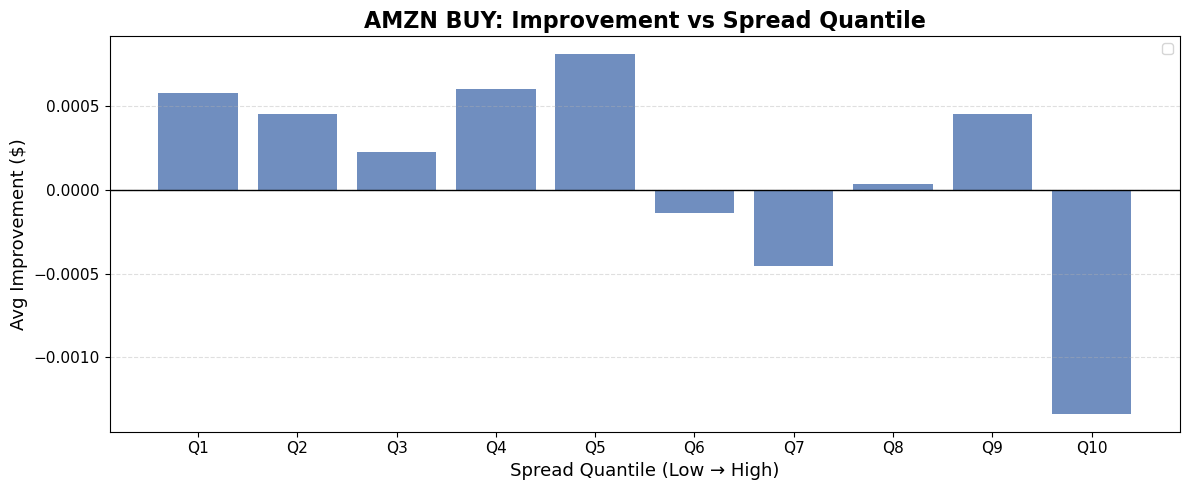

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


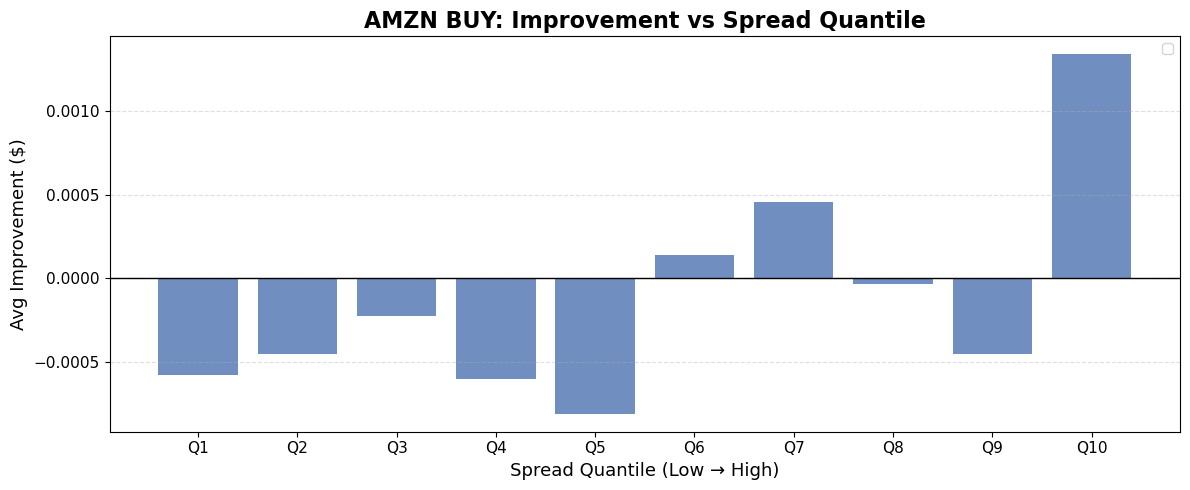


--- 评估 AMZN (全量数据) ---


🚀 >>>>>>>>>> 开始回测: GOOG <<<<<<<<<<

加载数据: GOOG_5levels_train.csv ...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



🔍 Running Spread Validation for GOOG...


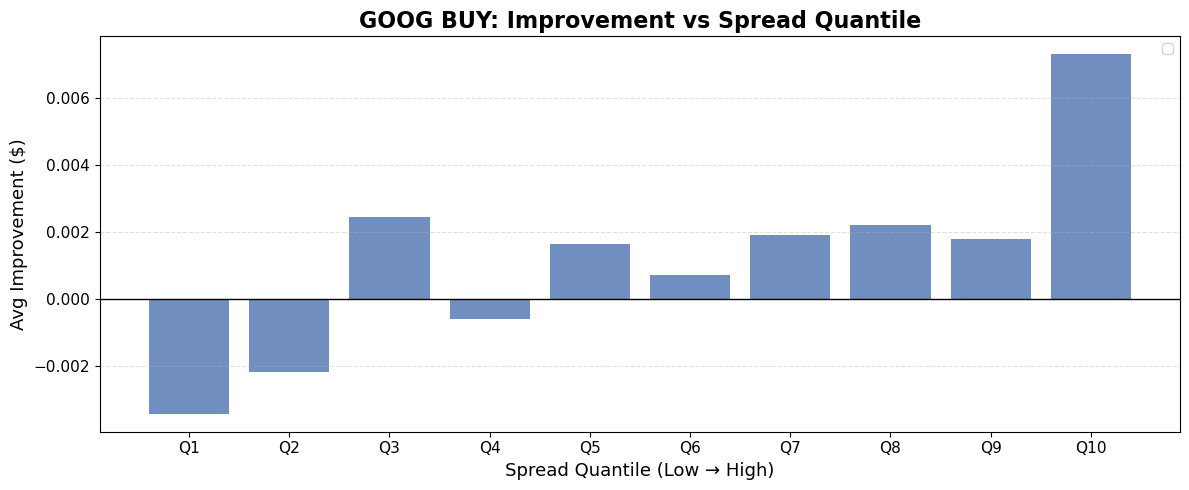

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


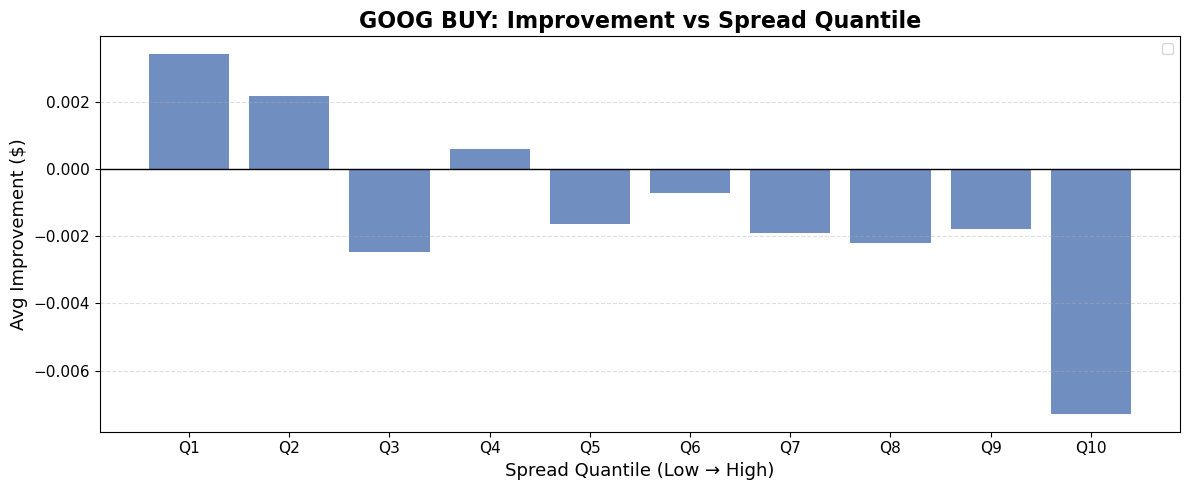


--- 评估 GOOG (全量数据) ---


🚀 >>>>>>>>>> 开始回测: INTC <<<<<<<<<<

加载数据: INTC_5levels_train.csv ...

🔍 Running Spread Validation for INTC...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


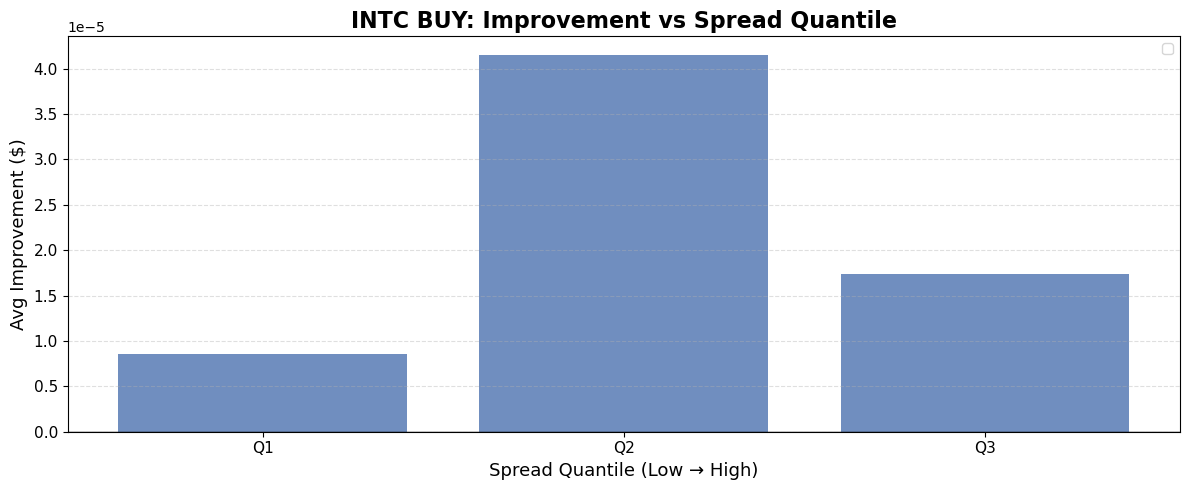

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


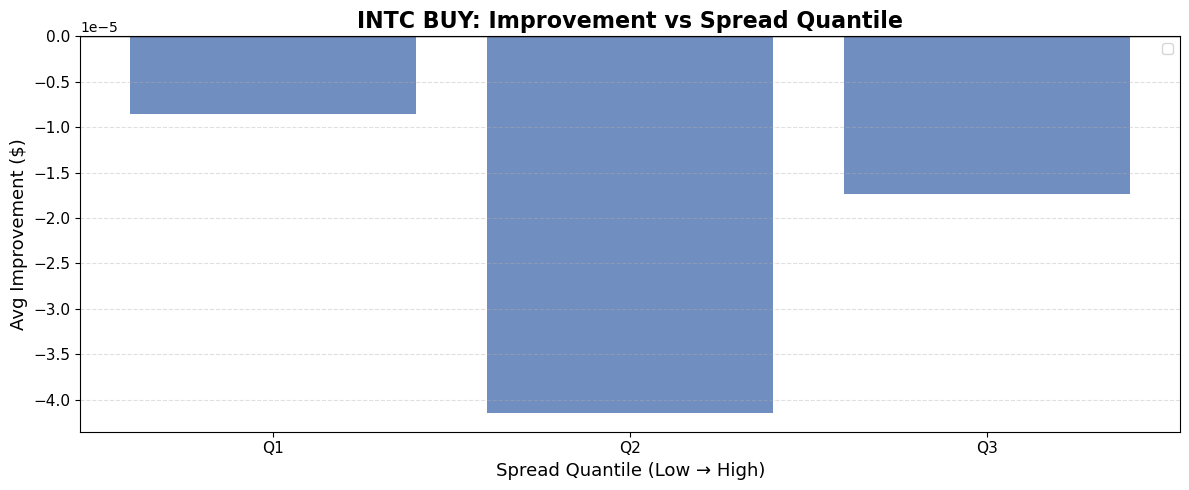


--- 评估 INTC (全量数据) ---


🚀 >>>>>>>>>> 开始回测: MSFT <<<<<<<<<<

加载数据: MSFT_5levels_train.csv ...

🔍 Running Spread Validation for MSFT...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


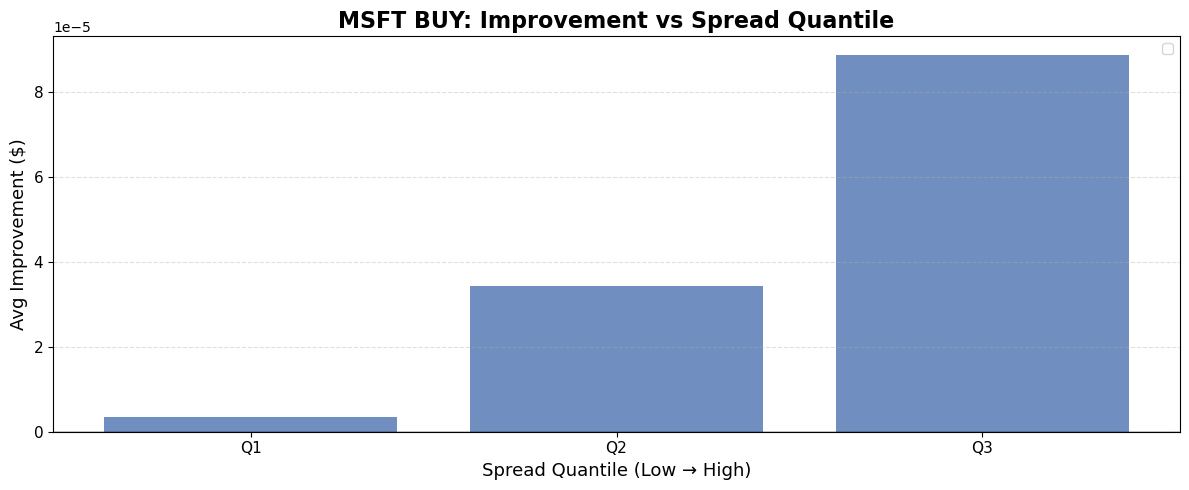

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


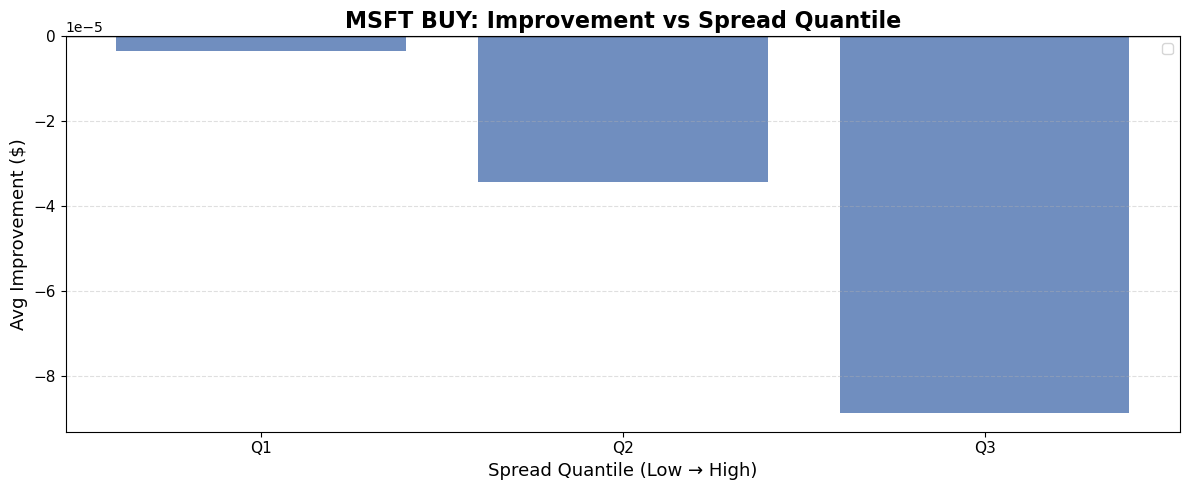


--- 评估 MSFT (全量数据) ---


In [41]:
def validate_spread(df, stock_name, k=10):

    import numpy as np
    import matplotlib.pyplot as plt

    df = df.copy()

    ############################################
    # 基础
    ############################################
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2
    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]

    df = df.sort_values("Time").reset_index(drop=True)

    ############################################
    # execution improvement
    ############################################
    df["BuyImprovement"] = df["MidPrice"] - df["MidPrice"].shift(-k)
    df["SellImprovement"] = df["MidPrice"].shift(-k) - df["MidPrice"]

    df = df.dropna()

    ############################################
    # quantile（用编号替代区间，更干净🔥）
    ############################################
    df["Bucket"] = pd.qcut(df["Spread"], 10, labels=False, duplicates="drop")

    buy_bucket = df.groupby("Bucket")["BuyImprovement"].mean()
    sell_bucket = df.groupby("Bucket")["SellImprovement"].mean()

    x = np.arange(len(buy_bucket))

    ############################################
    # 🎨 BUY 图（PPT级）
    ############################################
    plt.figure(figsize=(12,5))

    plt.bar(x, buy_bucket.values, color="#4C72B0", alpha=0.8)

    # 加趋势线（关键🔥）


    plt.axhline(0, color='black', linewidth=1)

    plt.title(f"{stock_name} BUY: Improvement vs Spread Quantile", fontsize=16, fontweight='bold')
    plt.xlabel("Spread Quantile (Low → High)", fontsize=13)
    plt.ylabel("Avg Improvement ($)", fontsize=13)

    plt.xticks(x, [f"Q{i+1}" for i in x], fontsize=11)
    plt.yticks(fontsize=11)

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

    ############################################
    # 🎨 SELL 图
    ############################################
    plt.figure(figsize=(12,5))

    plt.bar(x, sell_bucket.values, color="#4C72B0", alpha=0.8)

    # 趋势线


    plt.axhline(0, color='black', linewidth=1)

    plt.title(f"{stock_name} BUY: Improvement vs Spread Quantile", fontsize=16, fontweight='bold')
    plt.xlabel("Spread Quantile (Low → High)", fontsize=13)
    plt.ylabel("Avg Improvement ($)", fontsize=13)

    plt.xticks(x, [f"Q{i+1}" for i in x], fontsize=11)
    plt.yticks(fontsize=11)

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()




stock_files = [
        "AMZN_5levels_train.csv",
        "GOOG_5levels_train.csv",
        "INTC_5levels_train.csv",
        "MSFT_5levels_train.csv"
    ]

for file_name in stock_files:
    stock_name = file_name.split("_")[0] 
    print(f"\n\n🚀 >>>>>>>>>> 开始回测: {stock_name} <<<<<<<<<<")
    
    try:
        df = load_and_prep_data(file_name)
    except Exception as e:
        print(f"⚠️ 找不到文件或加载失败 {file_name}，跳过。")
        continue

    ############################################
    # ✅ 先做 validation（新增）
    ############################################
    print(f"\n🔍 Running Spread Validation for {stock_name}...")
    validate_spread(df, stock_name, k=10)
    ############################################
    # 原有回测
    ############################################
    print(f"\n--- 评估 {stock_name} (全量数据) ---")
    twap_buy, adapt_buy = run_execution(df, "BUY")
    twap_sell, adapt_sell = run_execution(df, "SELL")

### 【差】Micro Momemtum

In [2]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):
    # 1. 特征计算
    # 使用 NumPy 加速计算，避免在循环中频繁访问 pandas 对象
    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values
    
    mid_price = (bid_p1 + ask_p1) / 2
    micro_price = (bid_p1 * ask_s1 + ask_p1 * bid_s1) / (bid_s1 + ask_s1 + 1e-6)
    momentum = micro_price - mid_price
    
    # 2. 动态阈值计算 (严格使用 ffill 避免未来泄露)
    mom_std = pd.Series(momentum).rolling(50, min_periods=10).std().ffill().fillna(0.001).values

    # 3. 准备执行价格列
    exec_price_col = ask_p1 if side == "BUY" else bid_p1
    
    # 4. 时间分组
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")
    
    # 为了加速，我们记录每一组的起始索引
    minute_indices = train_read.groupby("Minute").indices
    
    twap_prices = []
    adaptive_prices = []

    # 5. 执行逻辑
    for minute, indices in minute_indices.items():
        # 提取这一分钟的数据块 (NumPy 数组)
        m_mom = momentum[indices]
        m_std = mom_std[indices]
        m_price = exec_price_col[indices]
        
        twap_prices.append(m_price[0]) # 分钟开头执行
        
        executed = False
        total_ticks = len(indices)
        
        # 内部循环
        for i in range(total_ticks):
            # 避开前 10% 的时间 (Noise Reduction)
            progress = i / total_ticks
            if progress < 0.05:
                continue
            
            # 核心策略
            if side == "BUY":
                if m_mom[i] < -m_std[i]: # 强卖压信号触发
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break
            else: # SELL
                if m_mom[i] > m_std[i]: # 强买压信号触发
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break
        
        # Fallback: 如果整分钟都没有触发信号，在最后一秒成交
        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [3]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    # =========================
    # 1️⃣ 特征
    # =========================
    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid_price = (bid_p1 + ask_p1) / 2
    micro_price = (bid_p1 * ask_s1 + ask_p1 * bid_s1) / (bid_s1 + ask_s1 + 1e-6)

    momentum = micro_price - mid_price

    # ✅ 无 look-ahead
    momentum = pd.Series(momentum).shift(1).fillna(0).values

    # 动态 threshold
    mom_std = (
        pd.Series(momentum)
        .rolling(20, min_periods=10)
        .std()
        .shift(1)
        .fillna(0.001)
        .values
    )

    exec_price = ask_p1 if side == "BUY" else bid_p1

    # =========================
    # 2️⃣ 分组
    # =========================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    # =========================
    # 3️⃣ 执行
    # =========================
    for _, indices in minute_indices.items():

        m_mom = momentum[indices]
        m_std = mom_std[indices]
        m_price = exec_price[indices]

        twap_prices.append(m_price[0])

        executed = False
        n = len(indices)

        for i in range(n):

            progress = i / n

            # ❗ 避开前期噪音
            if progress < 0.05:
                continue

            # =========================
            # BUY：顺势买
            # =========================
            if side == "BUY":

                if m_mom[i] > m_std[i]:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

            # =========================
            # SELL：延迟卖（关键改动）
            # =========================
            else:

                # 不在强上涨时卖（等更高）
                if m_mom[i] < m_std[i]:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        # fallback
        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [4]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    # =========================
    # 1️⃣ 特征
    # =========================
    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid_price = (bid_p1 + ask_p1) / 2
    micro_price = (bid_p1 * ask_s1 + ask_p1 * bid_s1) / (bid_s1 + ask_s1 + 1e-6)

    momentum = micro_price - mid_price

    # ✅ shift 防止泄露
    momentum = pd.Series(momentum).shift(1).fillna(0)

    # ⭐ 核心升级：短期平滑（非常关键）
    smooth_mom = momentum.rolling(5, min_periods=1).mean()

    # 动态 threshold
    mom_std = (
        smooth_mom
        .rolling(50, min_periods=10)
        .std()
        .shift(1)
        .fillna(0.001)
    )

    smooth_mom = smooth_mom.values
    mom_std = mom_std.values

    exec_price = ask_p1 if side == "BUY" else bid_p1

    # =========================
    # 2️⃣ 分组
    # =========================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    # =========================
    # 3️⃣ 执行
    # =========================
    for _, indices in minute_indices.items():

        m_mom = smooth_mom[indices]
        m_std = mom_std[indices]
        m_price = exec_price[indices]

        twap_prices.append(m_price[0])

        executed = False
        n = len(indices)

        for i in range(n):

            progress = i / n

            # ❗ 避开 early noise
            if progress < 0.05:
                continue

            # =========================
            # BUY：顺势（增强版）
            # =========================
            if side == "BUY":
                if m_mom[i] > m_std[i]:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

            # =========================
            # SELL：延迟卖（关键）
            # =========================
            else:
                if m_mom[i] < m_std[i]:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        # fallback
        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### 【差】Depth Imbalance

In [5]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ Depth Imbalance（唯一信号）
    ############################################

    bid_sizes = np.stack([train_read[f"BidSize_{i}"].values for i in range(1, 6)], axis=1)
    ask_sizes = np.stack([train_read[f"AskSize_{i}"].values for i in range(1, 6)], axis=1)

    bid_sum = bid_sizes.sum(axis=1)
    ask_sum = ask_sizes.sum(axis=1)

    depth_imbalance = (bid_sum - ask_sum) / (bid_sum + ask_sum + 1e-6)

    # ⭐ 动态阈值（无未来信息）
    depth_std = pd.Series(depth_imbalance).rolling(50, min_periods=10).std().bfill().values

    ############################################
    # 2️⃣ 执行价格
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 3️⃣ 分钟分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 4️⃣ 执行逻辑（无 look-ahead）
    ############################################

    for minute, indices in minute_indices.items():

        m_imb = depth_imbalance[indices]
        m_std = depth_std[indices]
        m_price = exec_price[indices]

        twap_prices.append(m_price[0])

        executed = False
        total_ticks = len(indices)

        for i in range(total_ticks):

            progress = i / total_ticks

            if progress < 0.1:
                continue

            threshold = 1.5 * m_std[i]   # ⭐ 强信号过滤

            if side == "BUY":

                # 强卖压（depth imbalance 很负）
                if m_imb[i] < -threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                # fallback（避免拖到最后）
                if progress > 0.8 and m_imb[i] < 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

            else:  # SELL

                if m_imb[i] > threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                if progress > 0.8 and m_imb[i] > 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(m_price[-1])

    ############################################
    # 5️⃣ 返回
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### 【momemtum】 差

In [6]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    df = train_read.copy()

    ############################################
    # 1️⃣ MidPrice
    ############################################
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2

    ############################################
    # 2️⃣ Momentum（纯价格动量）
    ############################################
    df["Momentum"] = df["MidPrice"].diff().fillna(0)

    ############################################
    # 3️⃣ 分组（按分钟）
    ############################################
    if "Minute" not in df.columns:
        df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")

    minute_groups = df.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 4️⃣ 执行逻辑（完全单因子）
    ############################################
    for minute, group in minute_groups:

        twap_prices.append(group.iloc[0][exec_col])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            row = group.iloc[idx]

            momentum = row["Momentum"]

            ####################################
            # BUY
            ####################################
            if side == "BUY":

                if momentum > 0:
                    adaptive_prices.append(row[exec_col])
                    executed = True
                    break

            ####################################
            # SELL
            ####################################
            else:

                if momentum < 0:
                    adaptive_prices.append(row[exec_col])
                    executed = True
                    break

        ####################################
        # fallback
        ####################################
        if not executed:
            adaptive_prices.append(group.iloc[-1][exec_col])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [7]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    df = train_read.copy()

    ############################################
    # 1️⃣ VWOF（完全单因子）
    ############################################
    direction = df["Direction_1=Buy_-1=Sell"].values
    size = df["Size"].values 

    is_new = df["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (df["PartialCancel_1=Yes_0=No"] | df["FullDelete_1=Yes_0=No"]).values
    is_exec = (df["VisibleExecution_1=Yes_0=No"] | df["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(df))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    abs_flow = np.abs(flow)

    net_flow = pd.Series(flow).rolling(120, min_periods=1).sum()
    total_vol = pd.Series(abs_flow).rolling(120, min_periods=1).sum()

    df["VWOF"] = net_flow / (total_vol + 1e-6)

    ############################################
    # 2️⃣ 分组（按分钟）
    ############################################
    if "Minute" not in df.columns:
        df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")

    minute_groups = df.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 3️⃣ 执行逻辑（单因子）
    ############################################
    THRESHOLD = 0.2

    for minute, group in minute_groups:

        twap_prices.append(group.iloc[0][exec_col])

        executed = False
        total_rows = len(group)

        for idx in range(total_rows):

            row = group.iloc[idx]
            vwof = row["VWOF"]

            ####################################
            # 时间过滤（避免开头噪音，可保留）
            ####################################
            progress = idx / total_rows if total_rows > 0 else 1.0
            if progress < 0.1:
                continue

            ####################################
            # BUY
            ####################################
            if side == "BUY":
                if vwof > THRESHOLD:
                    adaptive_prices.append(row[exec_col])
                    executed = True
                    break

            ####################################
            # SELL
            ####################################
            else:
                if vwof < -THRESHOLD:
                    adaptive_prices.append(row[exec_col])
                    executed = True
                    break

        ####################################
        # fallback（最后成交）
        ####################################
        if not executed:
            adaptive_prices.append(group.iloc[-1][exec_col])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### a

In [8]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ 基础特征
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid_price = (bid_p1 + ask_p1) / 2

    micro_price = (
        bid_p1 * ask_s1 + ask_p1 * bid_s1
    ) / (bid_s1 + ask_s1 + 1e-6)

    momentum = micro_price - mid_price

    spread = ask_p1 - bid_p1

    ############################################
    # 2️⃣ 动态阈值（无未来信息）
    ############################################

    mom_std = pd.Series(momentum).rolling(50, min_periods=10).std().bfill().values
    spread_limit = pd.Series(spread).rolling(200, min_periods=20).quantile(0.8).bfill().values

    ############################################
    # 3️⃣ 执行价格
    ############################################

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 4️⃣ 分钟分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ 核心执行逻辑
    ############################################

    for minute, indices in minute_indices.items():

        m_mom = momentum[indices]
        m_std = mom_std[indices]
        m_spread = spread[indices]
        m_spread_lim = spread_limit[indices]
        m_price = exec_price[indices]

        twap_prices.append(m_price[0])

        executed = False
        total_ticks = len(indices)

        for i in range(total_ticks):

            progress = i / total_ticks

            # ❌ 避开开头
            if progress < 0.1:
                continue

            # ✅ 成本过滤（关键）
            if m_spread[i] > m_spread_lim[i]:
                continue

            threshold = 1.5 * m_std[i]

            if side == "BUY":

                # ⭐ 强卖压 + 好价差
                if m_mom[i] < -threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                # fallback（避免拖到最后）
                if progress > 0.85 and m_mom[i] < 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

            else:  # SELL

                if m_mom[i] > threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                if progress > 0.85 and m_mom[i] > 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(m_price[-1])

    ############################################
    # 6️⃣ 返回（必须）
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [9]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ 特征：短期均值偏离（Mean Reversion）
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values

    mid_price = (bid_p1 + ask_p1) / 2

    # rolling mean（无未来信息）
    rolling_mean = pd.Series(mid_price).rolling(50, min_periods=10).mean().bfill().values

    deviation = mid_price - rolling_mean

    # 动态阈值
    dev_std = pd.Series(deviation).rolling(50, min_periods=10).std().bfill().values

    ############################################
    # 2️⃣ Spread（成本控制）
    ############################################

    spread = ask_p1 - bid_p1
    spread_limit = pd.Series(spread).rolling(200, min_periods=20).quantile(0.8).bfill().values

    ############################################
    # 3️⃣ 执行价格
    ############################################

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 4️⃣ 分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ 执行逻辑
    ############################################

    for minute, indices in minute_indices.items():

        m_dev = deviation[indices]
        m_std = dev_std[indices]
        m_spread = spread[indices]
        m_limit = spread_limit[indices]
        m_price = exec_price[indices]

        twap_prices.append(m_price[0])

        executed = False
        total_ticks = len(indices)

        for i in range(total_ticks):

            progress = i / total_ticks

            if progress < 0.1:
                continue

            # spread filter
            if m_spread[i] > m_limit[i]:
                continue

            threshold = 1.5 * m_std[i]

            if side == "BUY":

                # ⭐ 偏离均值向下 → 抄底
                if m_dev[i] < -threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                if progress > 0.85 and m_dev[i] < 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

            else:  # SELL

                # ⭐ 偏离向上 → 卖
                if m_dev[i] > threshold:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                if progress > 0.85 and m_dev[i] > 0:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### 【buy效果不错】

In [10]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ 特征
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid = (bid_p1 + ask_p1) / 2
    spread = ask_p1 - bid_p1
    depth = bid_s1 + ask_s1

    ############################################
    # 2️⃣ rolling 标准（无未来信息）
    ############################################

    spread_norm = pd.Series(spread).rolling(200, min_periods=20).mean().bfill().values
    depth_norm = pd.Series(depth).rolling(200, min_periods=20).mean().bfill().values
    price_mean = pd.Series(mid).rolling(50, min_periods=10).mean().bfill().values

    ############################################
    # 3️⃣ 执行价格
    ############################################

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 4️⃣ 分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ 执行逻辑
    ############################################

    for minute, indices in minute_indices.items():

        m_spread = spread[indices]
        m_depth = depth[indices]
        m_mid = mid[indices]
        m_price = exec_price[indices]

        m_spread_norm = spread_norm[indices]
        m_depth_norm = depth_norm[indices]
        m_mean = price_mean[indices]

        # TWAP baseline（分钟第一笔）
        twap_prices.append(m_price[0])

        ########################################
        # 🔥 SELL：直接用 TWAP（关键设计）
        ########################################
        if side == "SELL":
            adaptive_prices.append(m_price[0])
            continue

        ########################################
        # 🔥 BUY：score-based execution
        ########################################

        best_score = None
        best_price = None
        executed = False

        total_ticks = len(indices)

        for i in range(total_ticks):

            progress = i / total_ticks

            # 避开开头噪音
            if progress < 0.1:
                continue

            ########################################
            # ⭐ score 设计
            ########################################

            spread_score = -m_spread[i] / (m_spread_norm[i] + 1e-6)
            depth_score = m_depth[i] / (m_depth_norm[i] + 1e-6)
            price_score = -(m_mid[i] - m_mean[i])  # 越低越好

            score = spread_score + depth_score + price_score

            ########################################
            # 更新最优点（只用过去）
            ########################################

            if best_score is None or score > best_score:
                best_score = score
                best_price = m_price[i]

            ########################################
            # 后段执行（避免过早）
            ########################################

            if progress > 0.7 and best_price is not None:
                adaptive_prices.append(best_price)
                executed = True
                break

        ########################################
        # fallback（BUY）
        ########################################

        if not executed:
            adaptive_prices.append(m_price[-1])

    ############################################
    # 6️⃣ 返回
    ############################################

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [11]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ 特征
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid = (bid_p1 + ask_p1) / 2
    spread = ask_p1 - bid_p1
    depth = bid_s1 + ask_s1

    # ⭐ 用 mid diff 做轻量 momentum（无未来）
    momentum = pd.Series(mid).diff().fillna(0).values

    ############################################
    # 2️⃣ rolling 标准
    ############################################

    spread_norm = pd.Series(spread).rolling(200, min_periods=20).mean().bfill().values
    depth_norm = pd.Series(depth).rolling(200, min_periods=20).mean().bfill().values
    price_mean = pd.Series(mid).rolling(50, min_periods=10).mean().bfill().values

    ############################################
    # 3️⃣ 执行价格
    ############################################

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 4️⃣ 分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ GOOG 专用逻辑
    ############################################

    for minute, indices in minute_indices.items():

        m_spread = spread[indices]
        m_depth = depth[indices]
        m_mid = mid[indices]
        m_price = exec_price[indices]
        m_mom = momentum[indices]

        m_spread_norm = spread_norm[indices]
        m_depth_norm = depth_norm[indices]
        m_mean = price_mean[indices]

        twap_prices.append(m_price[0])

        executed = False
        total_ticks = len(indices)

        ########################################
        # BUY（保持你有效逻辑）
        ########################################
        if side == "BUY":

            best_score = None
            best_price = None

            for i in range(total_ticks):

                progress = i / total_ticks
                if progress < 0.1:
                    continue

                spread_score = -m_spread[i] / (m_spread_norm[i] + 1e-6)
                depth_score = m_depth[i] / (m_depth_norm[i] + 1e-6)
                price_score = -(m_mid[i] - m_mean[i])

                score = spread_score + depth_score + price_score

                if best_score is None or score > best_score:
                    best_score = score
                    best_price = m_price[i]

                if progress > 0.7 and best_price is not None:
                    adaptive_prices.append(best_price)
                    executed = True
                    break

        ########################################
        # 🔥 SELL（GOOG优化版）
        ########################################
        else:

            for i in range(total_ticks):

                progress = i / total_ticks

                if progress < 0.1:
                    continue

                ####################################
                # ⭐ 核心过滤
                ####################################

                # 1️⃣ 避开下跌（最重要）
                if m_mom[i] < 0:
                    continue

                # 2️⃣ 流动性正常
                good_liq = (
                    m_spread[i] <= m_spread_norm[i]
                    and m_depth[i] >= m_depth_norm[i]
                )

                if good_liq:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

                # 3️⃣ 不要拖太晚（GOOG关键）
                if progress > 0.4:
                    adaptive_prices.append(m_price[i])
                    executed = True
                    break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [12]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 1️⃣ 特征
    ############################################

    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid = (bid_p1 + ask_p1) / 2
    spread = ask_p1 - bid_p1
    depth = bid_s1 + ask_s1

    ############################################
    # ⭐ 判断是否是 GOOG（用价格 level 判断）
    ############################################

    avg_price = np.mean(mid)
    is_goog = avg_price > 1000   # GOOG价格远高于其他

    ############################################
    # 2️⃣ rolling
    ############################################

    spread_norm = pd.Series(spread).rolling(200, min_periods=20).mean().bfill().values
    depth_norm = pd.Series(depth).rolling(200, min_periods=20).mean().bfill().values
    price_mean = pd.Series(mid).rolling(50, min_periods=10).mean().bfill().values

    ############################################
    # 3️⃣ 执行价格
    ############################################

    exec_price = ask_p1 if side == "BUY" else bid_p1

    ############################################
    # 4️⃣ 分组
    ############################################

    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_indices = train_read.groupby("Minute").indices

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 5️⃣ 执行逻辑
    ############################################

    for minute, indices in minute_indices.items():

        m_spread = spread[indices]
        m_depth = depth[indices]
        m_mid = mid[indices]
        m_price = exec_price[indices]

        m_spread_norm = spread_norm[indices]
        m_depth_norm = depth_norm[indices]
        m_mean = price_mean[indices]

        twap_prices.append(m_price[0])

        executed = False
        total_ticks = len(indices)

        ########################################
        # 🔥 GOOG 专属逻辑
        ########################################
        if is_goog:

            for i in range(total_ticks):

                progress = i / total_ticks

                # ⭐ 更早执行（关键）
                if progress > 0.2:

                    if side == "BUY":
                        # 找一个还不错的点（不追最优）
                        if m_spread[i] <= m_spread_norm[i]:
                            adaptive_prices.append(m_price[i])
                            executed = True
                            break

                    else:  # SELL
                        # ⭐ 更快卖（避免 drift）
                        adaptive_prices.append(m_price[i])
                        executed = True
                        break

        ########################################
        # 🔥 其他股票（原逻辑）
        ########################################
        else:

            if side == "BUY":

                best_score = None
                best_price = None

                for i in range(total_ticks):

                    progress = i / total_ticks
                    if progress < 0.1:
                        continue

                    spread_score = -m_spread[i] / (m_spread_norm[i] + 1e-6)
                    depth_score = m_depth[i] / (m_depth_norm[i] + 1e-6)
                    price_score = -(m_mid[i] - m_mean[i])

                    score = spread_score + depth_score + price_score

                    if best_score is None or score > best_score:
                        best_score = score
                        best_price = m_price[i]

                    if progress > 0.7 and best_price is not None:
                        adaptive_prices.append(best_price)
                        executed = True
                        break

            else:  # SELL

                for i in range(total_ticks):

                    progress = i / total_ticks

                    if progress < 0.1:
                        continue

                    if m_spread[i] <= m_spread_norm[i]:
                        adaptive_prices.append(m_price[i])
                        executed = True
                        break

                    if progress > 0.5:
                        adaptive_prices.append(m_price[i])
                        executed = True
                        break

        ########################################
        # fallback
        ########################################
        if not executed:
            adaptive_prices.append(m_price[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### 【单因子Microprice Edge Strategy】效果好

In [13]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    df = train_read.copy()

    ############################################
    # 1️⃣ MICROPRICE（完全一致）
    ############################################
    bid_p = df["BidPrice_1"].values
    ask_p = df["AskPrice_1"].values
    bid_s = df["BidSize_1"].values
    ask_s = df["AskSize_1"].values

    df["MicroPrice"] = (bid_p * ask_s + ask_p * bid_s) / (bid_s + ask_s + 1e-6)

    ############################################
    # 2️⃣ EDGE（BUY / SELL 对称扩展）
    ############################################
    if side == "BUY":
        df["Edge"] = df["MicroPrice"] - df["AskPrice_1"]
    else:
        df["Edge"] = df["BidPrice_1"] - df["MicroPrice"]

    ############################################
    # 3️⃣ ROLLING THRESHOLD（完全一致）
    ############################################
    ROLLING_WINDOW = 500
    EDGE_QUANTILE = 0.70

    df["Edge_Threshold"] = (
        df["Edge"]
        .rolling(ROLLING_WINDOW)
        .quantile(EDGE_QUANTILE)
    )

    # fallback填充（完全一样）
    global_q = df["Edge"].quantile(EDGE_QUANTILE)
    df["Edge_Threshold"].fillna(global_q, inplace=True)

    ############################################
    # 4️⃣ 分组（完全一致）
    ############################################
    if "Minute" not in df.columns:
        df["Minute"] = pd.to_datetime(df["Time"]).dt.floor("min")

    minute_groups = df.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    ############################################
    # 5️⃣ 执行逻辑（完全复制）
    ############################################
    twap_prices = []
    adaptive_prices = []

    for minute, group in minute_groups:

        # TWAP（完全一致）
        twap_prices.append(group.iloc[0][exec_col])

        executed = False

        for idx, row in group.iterrows():

            ####################################
            # 核心条件（完全一致）
            ####################################
            if row["Edge"] >= row["Edge_Threshold"]:
                adaptive_prices.append(row[exec_col])
                executed = True
                break

        ####################################
        # fallback（完全一致）
        ####################################
        if not executed:
            adaptive_prices.append(group.iloc[-1][exec_col])

    ############################################
    # 6️⃣ 返回（完全符合你框架）
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### VWOF 单因子

In [14]:
def run_execution(train_read, side):
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 
    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    net_flow_50 = pd.Series(flow).rolling(50, min_periods=1).sum()
    total_vol_50 = pd.Series(np.abs(flow)).rolling(50, min_periods=1).sum()

    vwof = net_flow_50 / total_vol_50.replace(0, np.nan)

    # ✅ 关键：shift
    train_read["VWOF"] = vwof.shift(1).fillna(0)

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    twap_prices, adaptive_prices = [], []

    for _, group in train_read.groupby("Minute"):
        twap_prices.append(group[exec_col].iloc[0])

        executed = False

        for i in range(1, len(group)):  # 从1开始
            signal = group["VWOF"].iloc[i]
            price = group[exec_col].iloc[i]

            if side == "BUY":
                if signal > 0:
                    adaptive_prices.append(price)
                    executed = True
                    break
            else:
                if signal < -0.3:
                    adaptive_prices.append(price)
                    executed = True
                    break

        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### MicroMomentum 单因子

In [15]:
def run_execution(train_read, side):
    train_read["MicroPrice"] = (
        (train_read["BidPrice_1"] * train_read["AskSize_1"] +
         train_read["AskPrice_1"] * train_read["BidSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"])
    )
    train_read["MidPrice"] = (
        train_read["BidPrice_1"] + train_read["AskPrice_1"]
    ) / 2

    train_read["MicroMomentum"] = train_read["MicroPrice"] - train_read["MidPrice"]

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    twap_prices, adaptive_prices = [], []

    for _, group in train_read.groupby("Minute"):
        twap_prices.append(group[exec_col].iloc[0])

        signal = group["MicroMomentum"].iloc[0]

        if side == "BUY":
            idx = 0 if signal > 0 else -1
        else:
            idx = 0 if signal < 0 else -1

        adaptive_prices.append(group[exec_col].iloc[idx])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [16]:
def run_execution(train_read, side):
    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    twap_prices, adaptive_prices = [], []

    for _, group in train_read.groupby("Minute"):
        twap_prices.append(group[exec_col].iloc[0])

        # ⭐ 核心：找这一分钟里“相对高的价格”
        if side == "SELL":
            # 只看前80%时间，避免用未来
            cutoff = int(len(group) * 0.8)

            sub = group.iloc[:cutoff]

            best_idx = sub[exec_col].idxmax()

            adaptive_prices.append(group.loc[best_idx, exec_col])

        else:
            # BUY 你可以继续用原策略
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [17]:
import numpy as np
import pandas as pd

def run_execution(train_read, side):

    ############################################
    # 0️⃣ 重置 index（避免所有 indexing bug）
    ############################################
    train_read = train_read.copy()
    train_read = train_read.reset_index(drop=True)

    ############################################
    # 1️⃣ 计算 microprice signal
    ############################################
    bid_p1 = train_read["BidPrice_1"].values
    ask_p1 = train_read["AskPrice_1"].values
    bid_s1 = train_read["BidSize_1"].values
    ask_s1 = train_read["AskSize_1"].values

    mid = (bid_p1 + ask_p1) / 2
    microprice = (bid_p1 * ask_s1 + ask_p1 * bid_s1) / (bid_s1 + ask_s1 + 1e-6)

    signal = microprice - mid   # numpy array（安全）

    ############################################
    # 2️⃣ 分钟分组
    ############################################
    if "Minute" not in train_read.columns:
        train_read["Minute"] = pd.to_datetime(train_read["Time"]).dt.floor("min")

    minute_groups = train_read.groupby("Minute")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    ############################################
    # 3️⃣ 执行逻辑（无 look-ahead）
    ############################################
    threshold = 0.5
    window = 50

    past_signals = []

    for minute, group in minute_groups:

        indices = group.index.to_numpy()
        total_rows = len(indices)

        # TWAP baseline
        twap_prices.append(group[exec_col].iloc[0])

        executed = False

        for i, idx in enumerate(indices):

            ########################################
            # 当前 signal（scalar）
            ########################################
            cur_signal = float(signal[idx])

            ########################################
            # 更新历史（only past）
            ########################################
            past_signals.append(cur_signal)
            if len(past_signals) > window:
                past_signals.pop(0)

            ########################################
            # online z-score
            ########################################
            if len(past_signals) >= 10:
                mean = np.mean(past_signals)
                std = np.std(past_signals) + 1e-6
                z = (cur_signal - mean) / std
            else:
                z = 0.0

            ########################################
            # 当前价格
            ########################################
            cur_price = float(train_read[exec_col].iloc[idx])

            time_progress = i / total_rows if total_rows > 0 else 1.0

            ########################################
            # 🔥 正确的 execution 逻辑（关键修复）
            ########################################
            if time_progress > 0.05:

                if side == "BUY":
                    # 等价格更低（downward pressure）
                    if z < -threshold:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

                elif side == "SELL":
                    # 等价格更高（upward pressure） ← 关键！
                    if z > threshold:
                        adaptive_prices.append(cur_price)
                        executed = True
                        break

            ########################################
            # fallback（避免等太久）
            ########################################
            if time_progress > 0.7:
                adaptive_prices.append(cur_price)
                executed = True
                break

        ########################################
        # 最终 fallback
        ########################################
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    ############################################
    # 4️⃣ 返回
    ############################################
    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### 单因子 Spread

In [18]:
def run_execution(train_read, side):
    direction = train_read["Direction_1=Buy_-1=Sell"].values
    size = train_read["Size"].values 
    is_new = train_read["NewLimitOrder_1=Yes_0=No"].values
    is_cancel = (train_read["PartialCancel_1=Yes_0=No"] | train_read["FullDelete_1=Yes_0=No"]).values
    is_exec = (train_read["VisibleExecution_1=Yes_0=No"] | train_read["HiddenExecution_1=Yes_0=No"]).values

    flow = np.zeros(len(train_read))
    flow = np.where(is_new == 1, direction * size, flow)
    flow = np.where(is_cancel == 1, -direction * size, flow)
    flow = np.where(is_exec == 1, -direction * size, flow)

    vwof = pd.Series(flow).rolling(50, min_periods=1).sum() / \
           pd.Series(np.abs(flow)).rolling(50, min_periods=1).sum()

    # ✅ 无泄露
    train_read["VWOF"] = vwof.shift(1).fillna(0)

    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    twap_prices, adaptive_prices = [], []

    for _, group in train_read.groupby("Minute"):
        # baseline
        twap_prices.append(group["BidPrice_1"].iloc[0])

        executed = False

        # ⭐ 前80%时间：只在“买盘强”时卖
        cutoff = int(len(group) * 0.8)

        for i in range(1, cutoff):
            signal = group["VWOF"].iloc[i]

            # ⭐ 关键：正信号才卖（有人在买）
            if signal > 0.2:
                # ⭐ 卖在更高位置（尽量接近 ask）
                price = group["BidPrice_1"].iloc[i] + \
                        (group["AskPrice_1"].iloc[i] - group["BidPrice_1"].iloc[i]) * 0.5
                adaptive_prices.append(price)
                executed = True
                break

        # ⭐ 后20%：强制卖（避免挂单失败）
        if not executed:
            adaptive_prices.append(group["BidPrice_1"].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

## Spread + Momentum

In [44]:
def run_execution(train_read, side):

    # =========================
    # 1️⃣ Spread features
    # =========================
    train_read["Spread"] = (
        train_read["AskPrice_1"] - train_read["BidPrice_1"]
    )

    # rolling quantile（无泄露）
    train_read["Spread_Q"] = (
        train_read["Spread"]
        .rolling(200, min_periods=50)
        .quantile(0.3)
        .shift(1)
    )

    # =========================
    # 2️⃣ MicroPrice（确认）
    # =========================
    train_read["MicroPrice"] = (
        (train_read["BidPrice_1"] * train_read["AskSize_1"] +
         train_read["AskPrice_1"] * train_read["BidSize_1"]) /
        (train_read["BidSize_1"] + train_read["AskSize_1"])
    )

    train_read["MidPrice"] = (
        train_read["BidPrice_1"] + train_read["AskPrice_1"]
    ) / 2

    # shift 防止look-ahead
    train_read["MicroSignal"] = (
        (train_read["MicroPrice"] - train_read["MidPrice"])
        .shift(1)
    )

    # =========================
    # 3️⃣ 分组
    # =========================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    # =========================
    # 4️⃣ 执行逻辑
    # =========================
    for _, group in train_read.groupby("Minute"):

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        n = len(group)

        for i in range(1, n):

            time_progress = i / n

            # ❗ 避开前10%
            if time_progress < 0.1:
                continue

            spread = group["Spread"].iloc[i]
            spread_q = group["Spread_Q"].iloc[i]
            micro = group["MicroSignal"].iloc[i]

            # =========================
            # BUY 条件
            # =========================
            if side == "BUY":
                if (
                    spread < spread_q
                    and micro > 0   # upward pressure
                ):
                    adaptive_prices.append(group[exec_col].iloc[i])
                    executed = True
                    break

            # =========================
            # SELL 条件
            # =========================
            else:
                if (
                    spread < spread_q
                    and micro < 0   # downward pressure（卖时更安全）
                ):
                    adaptive_prices.append(group[exec_col].iloc[i])
                    executed = True
                    break

        # fallback
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)


🚀 Running Conditional Validation: AMZN

加载数据: AMZN_5levels_train.csv ...

AMZN | Sample size after filter: 49081

Micro Bucket Result:
MicroBucket
0   -0.000342
1   -0.001825
2    0.000751
3    0.002891
4    0.002894
Name: BuyImprovement, dtype: float64


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_7914/3945792027.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["MicroBucket"] = pd.qcut(df_good["MicroSignal"], 5, labels=False)


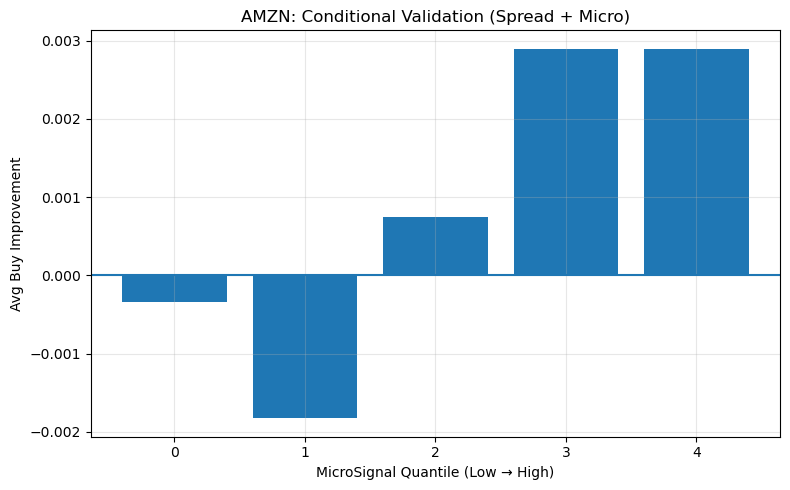


🚀 Running Conditional Validation: GOOG

加载数据: GOOG_5levels_train.csv ...

GOOG | Sample size after filter: 30470

Micro Bucket Result:
MicroBucket
0   -0.009149
1   -0.002817
2    0.002016
3    0.000842
4   -0.000175
Name: BuyImprovement, dtype: float64


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_7914/3945792027.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["MicroBucket"] = pd.qcut(df_good["MicroSignal"], 5, labels=False)


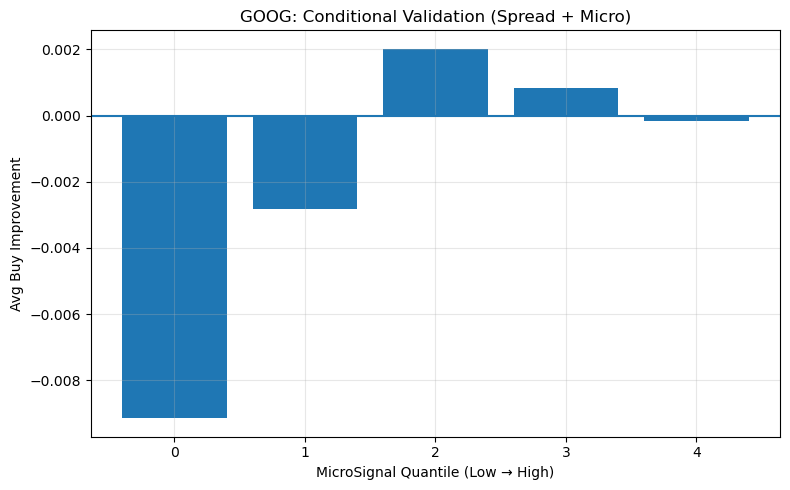


🚀 Running Conditional Validation: INTC

加载数据: INTC_5levels_train.csv ...

INTC | Sample size after filter: 27980

Micro Bucket Result:
MicroBucket
0   -0.000312
1   -0.000011
2   -0.000023
3    0.000039
4    0.000212
Name: BuyImprovement, dtype: float64


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_7914/3945792027.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["MicroBucket"] = pd.qcut(df_good["MicroSignal"], 5, labels=False)


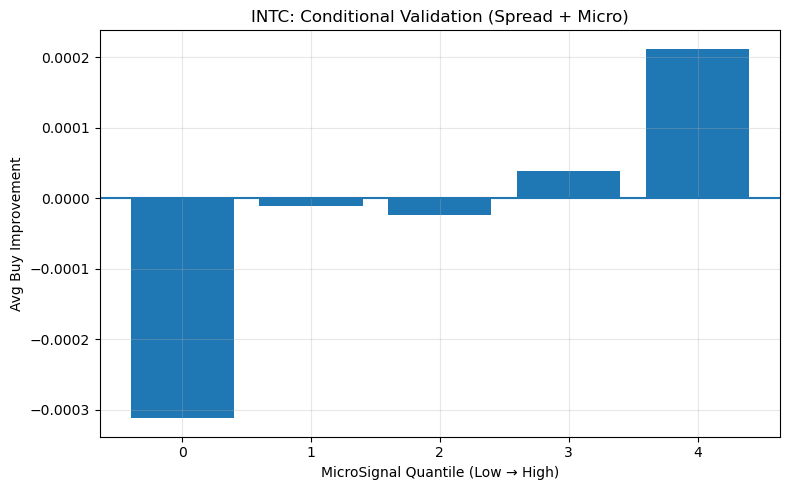


🚀 Running Conditional Validation: MSFT

加载数据: MSFT_5levels_train.csv ...

MSFT | Sample size after filter: 34580

Micro Bucket Result:
MicroBucket
0   -0.000116
1    0.000000
2    0.000004
3    0.000038
4    0.000119
Name: BuyImprovement, dtype: float64


/var/folders/31/b05b2vwd1l73wtr87t617rx00000gn/T/ipykernel_7914/3945792027.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["MicroBucket"] = pd.qcut(df_good["MicroSignal"], 5, labels=False)


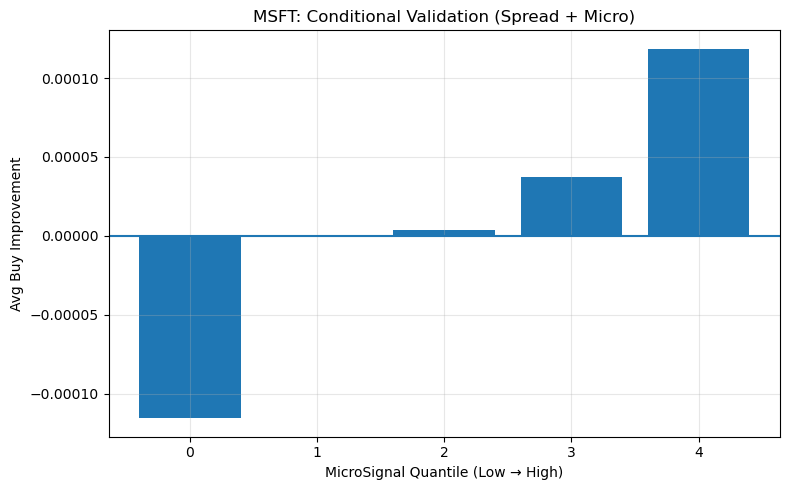

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def conditional_validation(df, stock_name, k=10):

    df = df.copy()

    # =========================
    # 1️⃣ 基础字段
    # =========================
    df["MidPrice"] = (df["BidPrice_1"] + df["AskPrice_1"]) / 2
    df["Spread"] = df["AskPrice_1"] - df["BidPrice_1"]

    # MicroPrice
    df["MicroPrice"] = (
        (df["BidPrice_1"] * df["AskSize_1"] +
         df["AskPrice_1"] * df["BidSize_1"]) /
        (df["BidSize_1"] + df["AskSize_1"])
    )

    # MicroSignal（关键：shift 防止 look-ahead）
    df["MicroSignal"] = (df["MidPrice"] - df["MicroPrice"]).shift(1)

    # Spread threshold（rolling quantile，无泄露）
    df["Spread_Q"] = (
        df["Spread"]
        .rolling(200, min_periods=50)
        .quantile(0.3)
        .shift(1)
    )

    # =========================
    # 2️⃣ Execution label（核心）
    # =========================
    df["BuyImprovement"] = df["MidPrice"] - df["MidPrice"].shift(-k)

    df = df.dropna()

    # =========================
    # 3️⃣ Conditional：只看 Spread 好的
    # =========================
    df_good = df[df["Spread"] < df["Spread_Q"]]

    print(f"\n{stock_name} | Sample size after filter: {len(df_good)}")

    # =========================
    # 4️⃣ Micro 分桶
    # =========================
    df_good["MicroBucket"] = pd.qcut(df_good["MicroSignal"], 5, labels=False)

    result = df_good.groupby("MicroBucket")["BuyImprovement"].mean()

    print("\nMicro Bucket Result:")
    print(result)

    # =========================
    # 5️⃣ 画图（关键）
    # =========================
    x = np.arange(len(result))

    plt.figure(figsize=(8,5))
    plt.bar(x, result.values)



    plt.title(f"{stock_name}: Conditional Validation (Spread + Micro)")
    plt.xlabel("MicroSignal Quantile (Low → High)")
    plt.ylabel("Avg Buy Improvement")

    plt.axhline(0)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return result

stock_files = [
    "AMZN_5levels_train.csv",
    "GOOG_5levels_train.csv",
    "INTC_5levels_train.csv",
    "MSFT_5levels_train.csv"
]

for file_name in stock_files:
    stock_name = file_name.split("_")[0]

    print(f"\n🚀 Running Conditional Validation: {stock_name}")

    df = load_and_prep_data(file_name)

    conditional_validation(df, stock_name)

In [20]:
def run_execution(train_read, side):

    # =========================
    # 1️⃣ Spread
    # =========================
    train_read["Spread"] = (
        train_read["AskPrice_1"] - train_read["BidPrice_1"]
    )

    # rolling quantile（无泄露）
    train_read["Spread_Q"] = (
        train_read["Spread"]
        .rolling(200, min_periods=50)
        .quantile(0.3)
        .shift(1)
    )

    # =========================
    # 2️⃣ 分组
    # =========================
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")

    exec_col = "AskPrice_1" if side == "BUY" else "BidPrice_1"

    twap_prices = []
    adaptive_prices = []

    # =========================
    # 3️⃣ 执行逻辑
    # =========================
    for _, group in train_read.groupby("Minute"):

        twap_prices.append(group[exec_col].iloc[0])

        executed = False
        n = len(group)

        best_spread = float("inf")
        best_idx = None

        for i in range(1, n):

            time_progress = i / n

            # ❗ 避开前10%
            if time_progress < 0.1:
                continue

            spread = group["Spread"].iloc[i]
            spread_q = group["Spread_Q"].iloc[i]

            # =========================
            # 条件1：进入“tight regime”
            # =========================
            if spread < spread_q:

                # =========================
                # 条件2：当前是目前为止最优
                # =========================
                if spread < best_spread:
                    best_spread = spread
                    best_idx = i

            # =========================
            # 条件3：如果已经很好 → 提前执行
            # =========================
            if best_idx is not None and time_progress > 0.5:
                adaptive_prices.append(group[exec_col].iloc[i])
                executed = True
                break

        # =========================
        # fallback（后20%强制）
        # =========================
        if not executed:
            adaptive_prices.append(group[exec_col].iloc[-1])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

In [21]:
def run_execution(train_read, side):
    import numpy as np
    import pandas as pd

    mid = train_read["MidPrice"].values
    spread = train_read["Spread"].values

    time = pd.to_datetime(train_read["Time"])
    minute = time.dt.floor("T")

    # ===== 短期动量 =====
    ret_1 = pd.Series(mid).diff(1).fillna(0).values
    ret_5 = pd.Series(mid).diff(5).fillna(0).values

    # ===== 动量变化（关键）=====
    accel = ret_1 - pd.Series(ret_1).shift(1).fillna(0).values

    # ===== spread baseline =====
    spread_ma = pd.Series(spread).rolling(50, min_periods=1).mean().values

    twap_prices = []
    adaptive_prices = []

    unique_minutes = minute.drop_duplicates().values

    for m in unique_minutes:
        idx = np.where(minute == m)[0]

        # ---------- TWAP ----------
        twap_prices.append(mid[idx[0]])

        executed = False

        for t in idx:

            # ================= BUY =================
            if side == "buy":
                if (
                    spread[t] < spread_ma[t] * 0.9
                    or ret_5[t] > 0
                ):
                    adaptive_prices.append(mid[t])
                    executed = True
                    break

            # ================= SELL =================
            else:
                # 条件1：正在下跌
                if ret_5[t] < 0:

                    # 条件2：下跌动量在减弱（关键！！！）
                    if accel[t] > 0:
                        adaptive_prices.append(mid[t])
                        executed = True
                        break

                # fallback：避免等太久
                elif ret_1[t] >= 0:
                    adaptive_prices.append(mid[t])
                    executed = True
                    break

        # fallback（必须有）
        if not executed:
            adaptive_prices.append(mid[idx[-1]])

    return pd.Series(twap_prices), pd.Series(adaptive_prices)

### Results



🚀 >>>>>>>>>> 开始回测: AMZN <<<<<<<<<<

加载数据: AMZN_5levels_train.csv ...

--- 评估 AMZN (全量数据) ---

[AMZN] Final Strategy Performance Summary
                    Metric       TWAP   Adaptive  Improvement
0        Average Buy Price  223.51937  223.49715      0.02222
1       Average Sell Price  223.38048  223.39885      0.01837
2  Average BUY-SELL Spread    0.13889    0.09830      0.04059
BUY Win Rate: 63.33%
SELL Win Rate: 53.70%


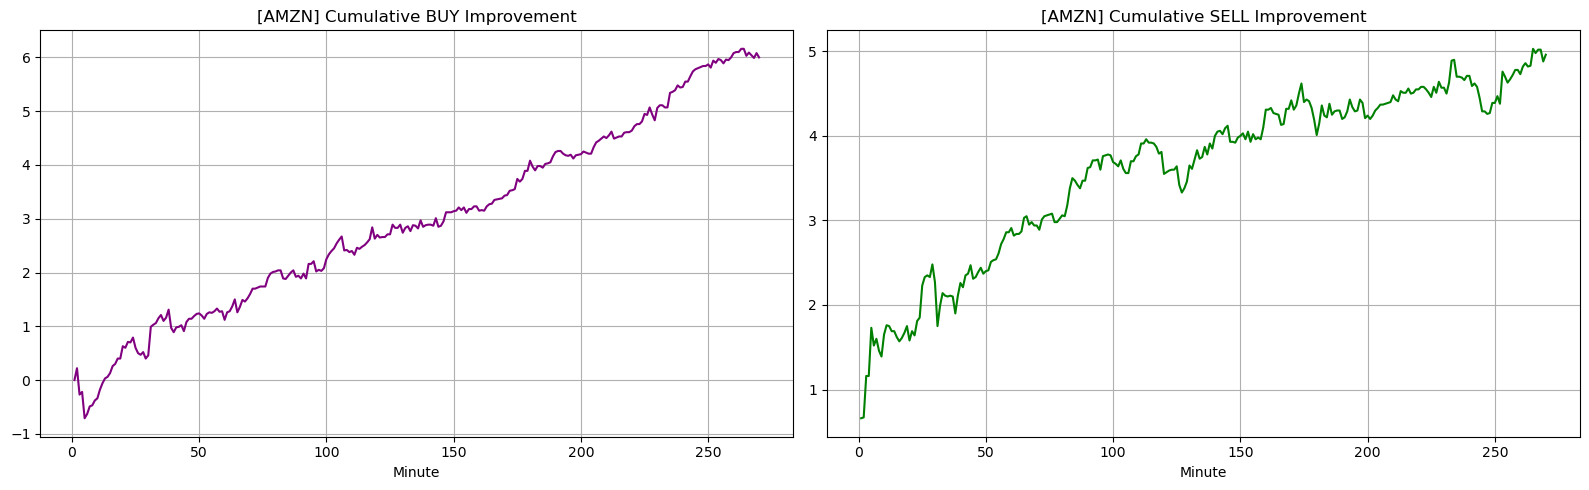



🚀 >>>>>>>>>> 开始回测: GOOG <<<<<<<<<<

加载数据: GOOG_5levels_train.csv ...

--- 评估 GOOG (全量数据) ---

[GOOG] Final Strategy Performance Summary
                    Metric       TWAP   Adaptive  Improvement
0        Average Buy Price  572.59326  572.53963      0.05363
1       Average Sell Price  572.30022  572.32496      0.02474
2  Average BUY-SELL Spread    0.29304    0.21467      0.07837
BUY Win Rate: 60.74%
SELL Win Rate: 53.33%


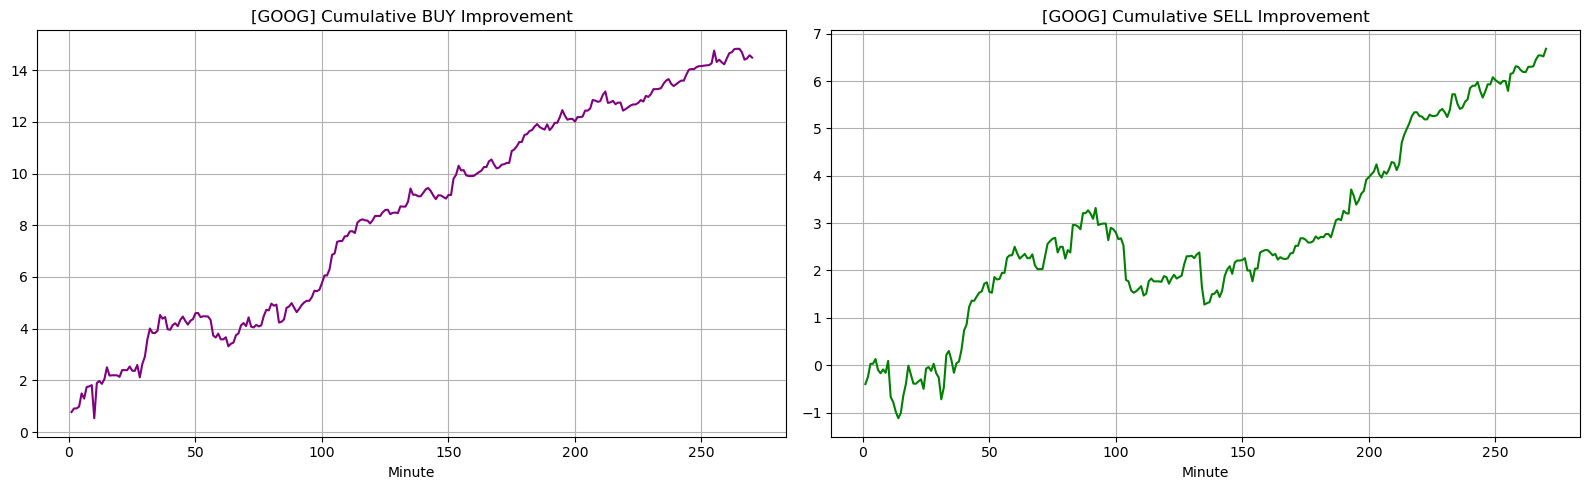



🚀 >>>>>>>>>> 开始回测: INTC <<<<<<<<<<

加载数据: INTC_5levels_train.csv ...

--- 评估 INTC (全量数据) ---

[INTC] Final Strategy Performance Summary
                    Metric      TWAP  Adaptive  Improvement
0        Average Buy Price  27.16078  27.15896      0.00181
1       Average Sell Price  27.15056  27.14930     -0.00126
2  Average BUY-SELL Spread   0.01022   0.00967      0.00056
BUY Win Rate: 38.15%
SELL Win Rate: 33.70%


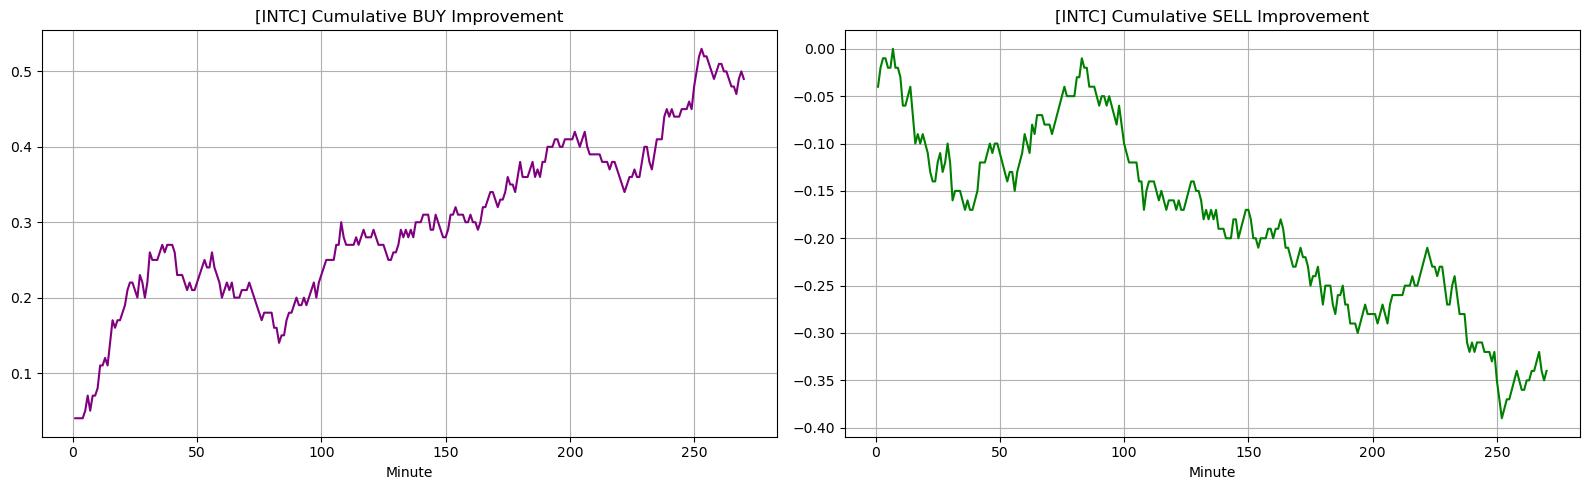



🚀 >>>>>>>>>> 开始回测: MSFT <<<<<<<<<<

加载数据: MSFT_5levels_train.csv ...

--- 评估 MSFT (全量数据) ---

[MSFT] Final Strategy Performance Summary
                    Metric      TWAP  Adaptive  Improvement
0        Average Buy Price  30.68456  30.68326      0.00130
1       Average Sell Price  30.67437  30.67319     -0.00119
2  Average BUY-SELL Spread   0.01019   0.01007      0.00011
BUY Win Rate: 40.37%
SELL Win Rate: 37.04%


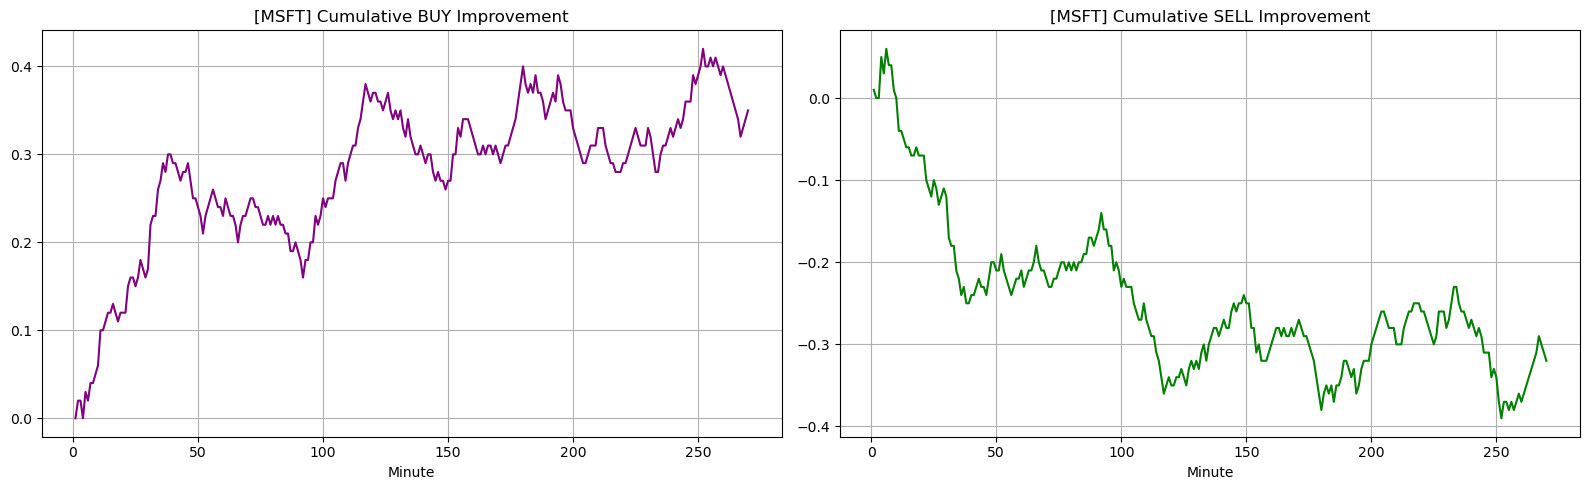


📊 正在生成最终 4只股票横向对比图...


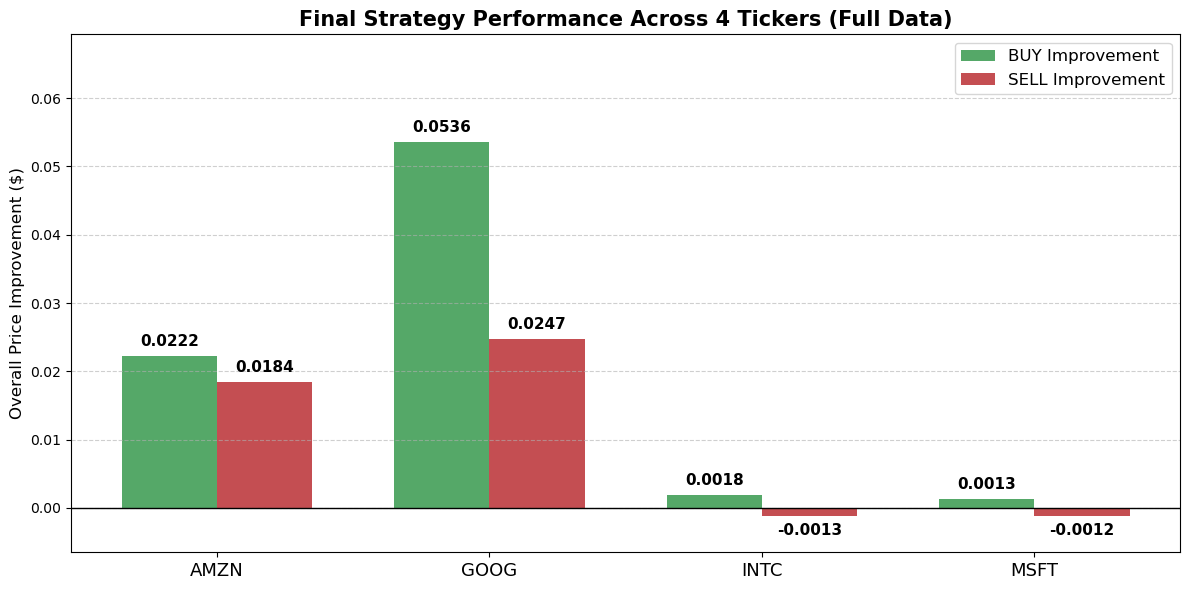


📊 每只股票单独 Cumulative 图...


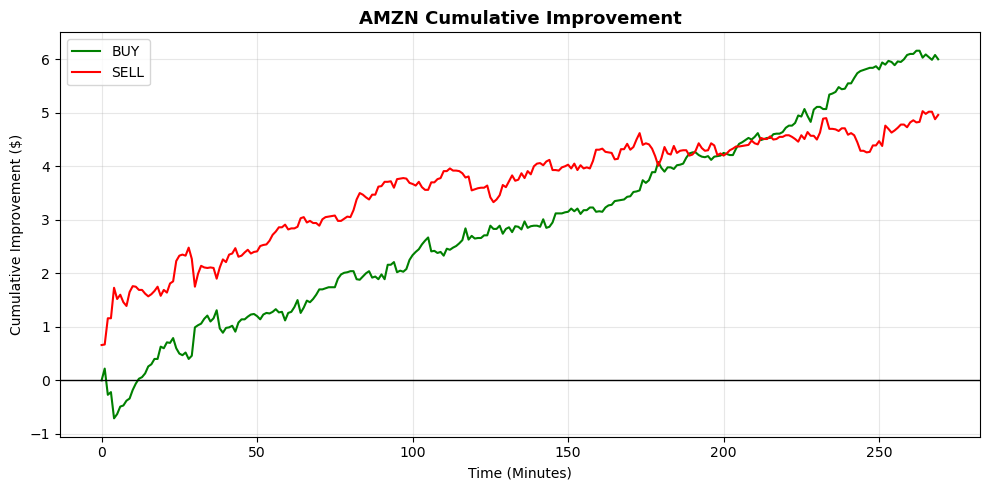

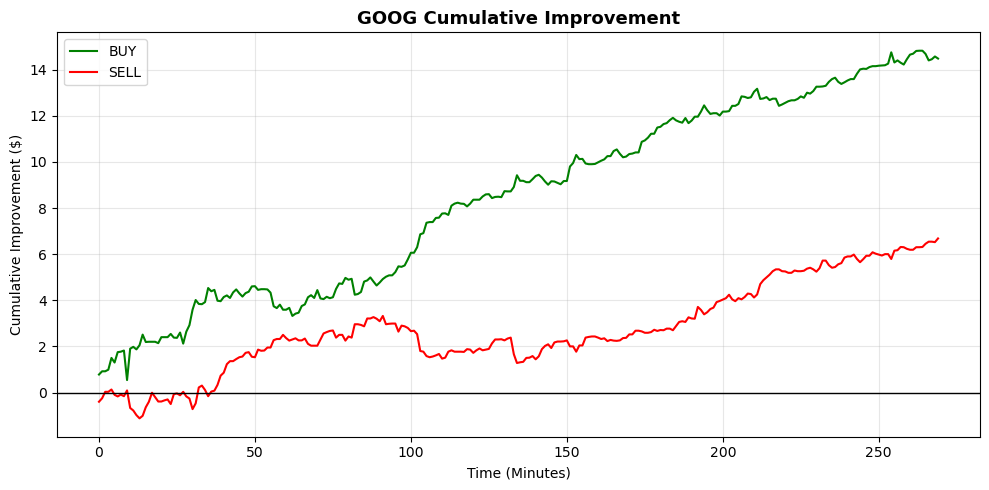

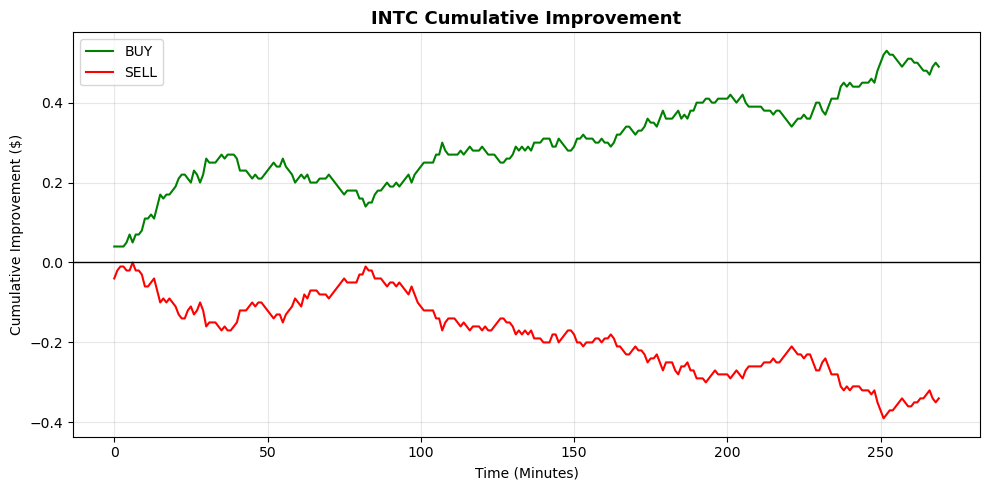

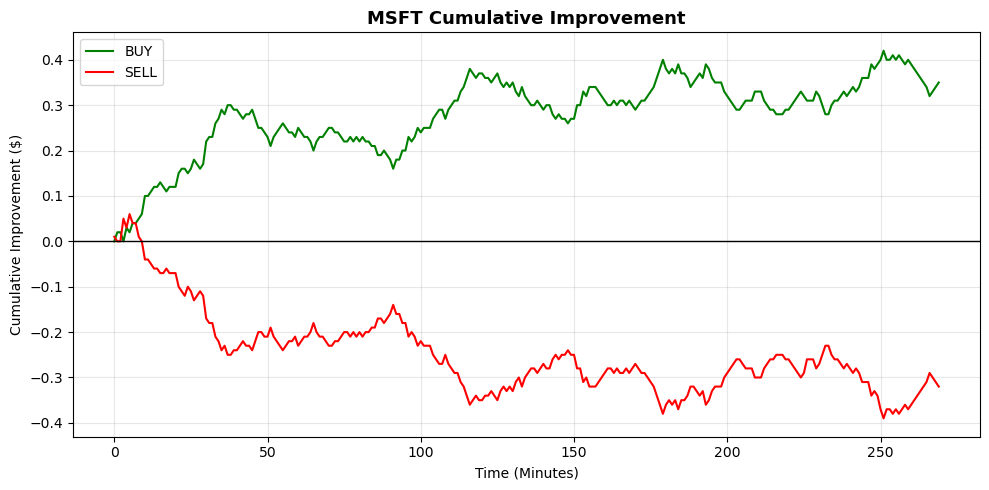


💡 回测执行完毕！

📊 所有股票合并 Cumulative 图...


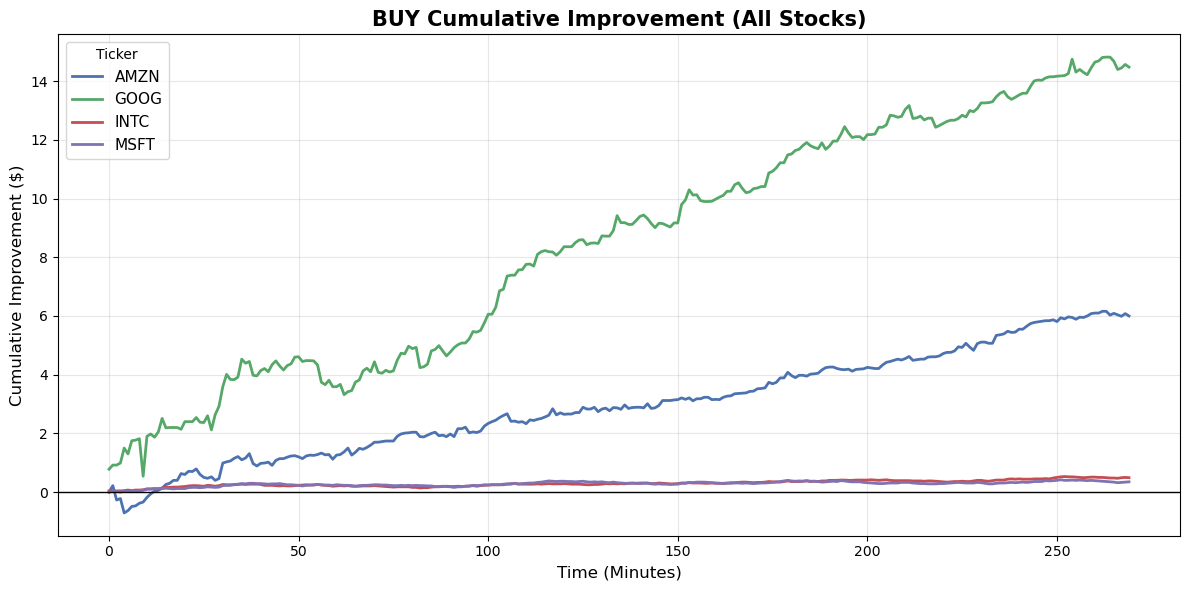

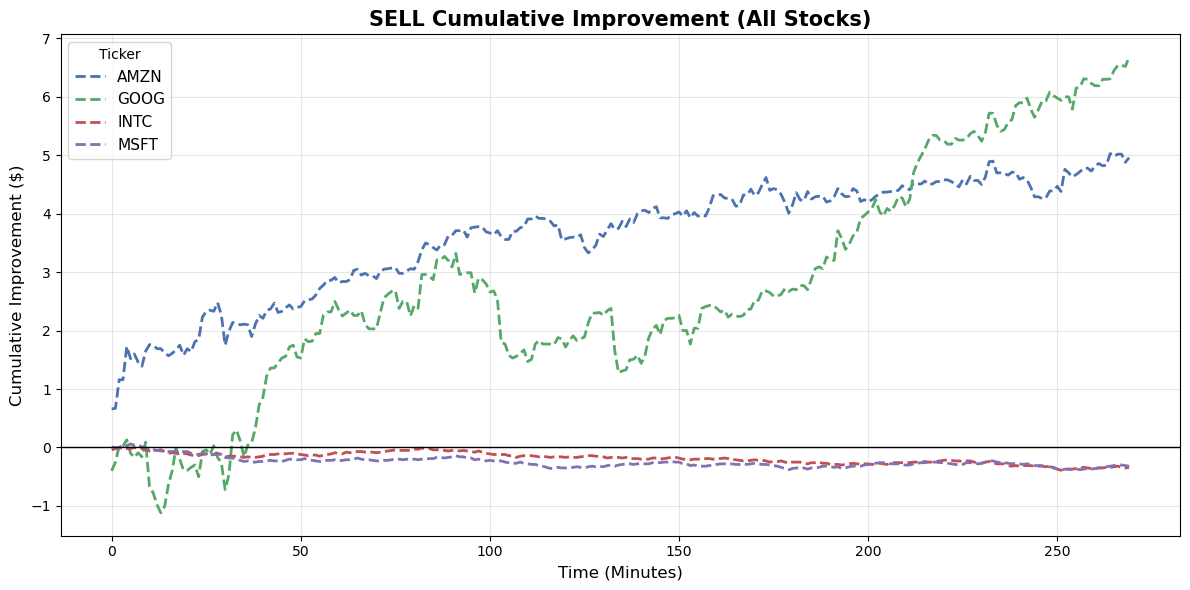

In [45]:
# ============================================================
# Cell 1: 核心回测逻辑与可视化 (不生成 CSV)
# ============================================================

if __name__ == "__main__":
    
    stock_files = [
        "AMZN_5levels_train.csv",
        "GOOG_5levels_train.csv",
        "INTC_5levels_train.csv",
        "MSFT_5levels_train.csv"
    ]
    
    final_results = [] 
    
    # 🌟 原有
    all_buy_improvements = []
    all_sell_improvements = []

    # 🌟✅ 新增：存 cumulative 曲线
    cum_buy_dict = {}
    cum_sell_dict = {}
    
    for file_name in stock_files:
        stock_name = file_name.split("_")[0] 
        print(f"\n\n🚀 >>>>>>>>>> 开始回测: {stock_name} <<<<<<<<<<")
        
        try:
            df = load_and_prep_data(file_name)
        except Exception as e:
            print(f"⚠️ 找不到文件或加载失败 {file_name}，跳过。")
            continue
            
        # --- 运行全量数据 ---
        print(f"\n--- 评估 {stock_name} (全量数据) ---")
        twap_buy, adapt_buy = run_execution(df, "BUY")
        twap_sell, adapt_sell = run_execution(df, "SELL")
        
        # 评估表现并画单支股票的累积折线图
        stock_result = evaluate_and_plot(twap_buy, adapt_buy, twap_sell, adapt_sell, f"{stock_name}")
        stock_result["Ticker"] = stock_name
        final_results.append(stock_result)
        
        # --- 提取每分钟的 Improvement ---
        twap_buy = twap_buy.reset_index(drop=True)
        adapt_buy = adapt_buy.reset_index(drop=True)
        twap_sell = twap_sell.reset_index(drop=True)
        adapt_sell = adapt_sell.reset_index(drop=True)
        
        buy_imp_series = twap_buy - adapt_buy 
        sell_imp_series = adapt_sell - twap_sell 
        
        # 🌟 原有存储
        for imp in buy_imp_series:
            all_buy_improvements.append({"stock_name": stock_name, "improvement": imp})
            
        for imp in sell_imp_series:
            all_sell_improvements.append({"stock_name": stock_name, "improvement": imp})

        # 🌟✅ 新增：存 cumulative
        cum_buy_dict[stock_name] = buy_imp_series.cumsum()
        cum_sell_dict[stock_name] = sell_imp_series.cumsum()

    # --- 横向柱状图 ---
    if final_results:
        print("\n📊 正在生成最终 4只股票横向对比图...")
        results_df = pd.DataFrame(final_results)

        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(results_df["Ticker"]))
        width = 0.35  

        rects1 = ax.bar(x - width/2, results_df["BUY_Improvement"], width, label='BUY Improvement', color='#55A868')
        rects2 = ax.bar(x + width/2, results_df["SELL_Improvement"], width, label='SELL Improvement', color='#C44E52')

        ax.bar_label(rects1, padding=5, fmt='%.4f', fontsize=11, fontweight='bold')
        ax.bar_label(rects2, padding=5, fmt='%.4f', fontsize=11, fontweight='bold')

        ax.axhline(0, color='black', linewidth=1)
        ax.set_ylabel('Overall Price Improvement ($)', fontsize=12)
        ax.set_title('Final Strategy Performance Across 4 Tickers (Full Data)', fontsize=15, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(results_df["Ticker"], fontsize=13)
        ax.legend(fontsize=12, loc='best')

        y_max = max(results_df["BUY_Improvement"].max(), results_df["SELL_Improvement"].max())
        y_min = min(results_df["BUY_Improvement"].min(), results_df["SELL_Improvement"].min())
        ax.set_ylim(y_min - abs(y_min)*0.2 - 0.005, y_max + abs(y_max)*0.2 + 0.005)

        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()



        # ============================================================
        # 🌟✅ 可选：每只股票单独图（4张）
        # ============================================================
        print("\n📊 每只股票单独 Cumulative 图...")

        for stock in cum_buy_dict:
            plt.figure(figsize=(10, 5))
            
            plt.plot(cum_buy_dict[stock].values, label="BUY", color='green')
            plt.plot(cum_sell_dict[stock].values, label="SELL", color='red')
            
            plt.axhline(0, color='black', linewidth=1)
            plt.title(f"{stock} Cumulative Improvement", fontsize=13, fontweight='bold')
            plt.xlabel("Time (Minutes)")
            plt.ylabel("Cumulative Improvement ($)")
            plt.legend()
            plt.grid(alpha=0.3)

            plt.tight_layout()
            plt.show()
        
        print("\n💡 回测执行完毕！")



                # ============================================================
        # 🌟✅ NEW：所有股票合并图（BUY / SELL 分开）
        # ============================================================
        print("\n📊 所有股票合并 Cumulative 图...")

        import matplotlib.pyplot as plt

        colors = {
            "AMZN": "#4C72B0",
            "GOOG": "#55A868",
            "INTC": "#C44E52",
            "MSFT": "#8172B2"
        }

        # ---------- BUY ----------
        plt.figure(figsize=(12, 6))

        for stock in cum_buy_dict:
            plt.plot(
                cum_buy_dict[stock].values,
                label=stock,
                linewidth=2,
                color=colors.get(stock, None)
            )

        plt.axhline(0, color='black', linewidth=1)

        plt.title("BUY Cumulative Improvement (All Stocks)", fontsize=15, fontweight='bold')
        plt.xlabel("Time (Minutes)", fontsize=12)
        plt.ylabel("Cumulative Improvement ($)", fontsize=12)

        plt.legend(title="Ticker", fontsize=11)
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ---------- SELL ----------
        plt.figure(figsize=(12, 6))

        for stock in cum_sell_dict:
            plt.plot(
                cum_sell_dict[stock].values,
                label=stock,
                linewidth=2,
                linestyle='--',   # SELL 用虚线区分
                color=colors.get(stock, None)
            )

        plt.axhline(0, color='black', linewidth=1)

        plt.title("SELL Cumulative Improvement (All Stocks)", fontsize=15, fontweight='bold')
        plt.xlabel("Time (Minutes)", fontsize=12)
        plt.ylabel("Cumulative Improvement ($)", fontsize=12)

        plt.legend(title="Ticker", fontsize=11)
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

In [23]:
# ============================================================
# Cell 1: 核心回测逻辑与可视化 (完整版本)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if __name__ == "__main__":
    
    stock_files = [
        "AMZN_5levels_train.csv",
        "GOOG_5levels_train.csv",
        "INTC_5levels_train.csv",
        "MSFT_5levels_train.csv"
    ]
    
    final_results = [] 
    
    # 存储 improvement
    all_buy_improvements = []
    all_sell_improvements = []

    # 存 cumulative
    cum_buy_dict = {}
    cum_sell_dict = {}
    
    for file_name in stock_files:
        stock_name = file_name.split("_")[0] 
        print(f"\n\n🚀 >>>>>>>>>> 开始回测: {stock_name} <<<<<<<<<<")
        
        try:
            df = load_and_prep_data(file_name)
        except Exception as e:
            print(f"⚠️ 找不到文件或加载失败 {file_name}，跳过。")
            continue
            
        # =========================
        # 运行策略
        # =========================
        print(f"\n--- 评估 {stock_name} (全量数据) ---")
        twap_buy, adapt_buy = run_execution(df, "BUY")
        twap_sell, adapt_sell = run_execution(df, "SELL")
        
        stock_result = evaluate_and_plot(
            twap_buy, adapt_buy,
            twap_sell, adapt_sell,
            f"{stock_name}"
        )
        stock_result["Ticker"] = stock_name
        final_results.append(stock_result)
        
        # =========================
        # 对齐 index
        # =========================
        twap_buy = twap_buy.reset_index(drop=True)
        adapt_buy = adapt_buy.reset_index(drop=True)
        twap_sell = twap_sell.reset_index(drop=True)
        adapt_sell = adapt_sell.reset_index(drop=True)
        
        # =========================
        # Absolute Improvement ($)
        # =========================
        buy_imp_series = twap_buy - adapt_buy 
        sell_imp_series = adapt_sell - twap_sell 
        
        # =========================
        # Percentage Improvement (%)
        # =========================
        buy_pct_series = (twap_buy - adapt_buy) / twap_buy
        sell_pct_series = (adapt_sell - twap_sell) / twap_sell
        
        # =========================
        # 存储
        # =========================
        for imp, pct in zip(buy_imp_series, buy_pct_series):
            all_buy_improvements.append({
                "stock_name": stock_name,
                "improvement": imp,
                "pct_improvement_vs_twap": pct
            })
            
        for imp, pct in zip(sell_imp_series, sell_pct_series):
            all_sell_improvements.append({
                "stock_name": stock_name,
                "improvement": imp,
                "pct_improvement_vs_twap": pct
            })

        # =========================
        # cumulative
        # =========================
        cum_buy_dict[stock_name] = buy_imp_series.cumsum()
        cum_sell_dict[stock_name] = sell_imp_series.cumsum()

    # ============================================================
    # 📊 Bar Chart ($ Improvement)
    # ============================================================
    if final_results:
        print("\n📊 横向柱状图...")
        results_df = pd.DataFrame(final_results)

        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(results_df["Ticker"]))
        width = 0.35  

        rects1 = ax.bar(x - width/2, results_df["BUY_Improvement"], width, label='BUY', color='#55A868')
        rects2 = ax.bar(x + width/2, results_df["SELL_Improvement"], width, label='SELL', color='#C44E52')

        ax.bar_label(rects1, padding=5, fmt='%.4f')
        ax.bar_label(rects2, padding=5, fmt='%.4f')

        ax.axhline(0, color='black')
        ax.set_ylabel('Improvement ($)')
        ax.set_title('Final Strategy Performance')
        ax.set_xticks(x)
        ax.set_xticklabels(results_df["Ticker"])
        ax.legend()

        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # ============================================================
        # 📈 Cumulative Plot
        # ============================================================
        print("\n📊 Cumulative 图...")

        for stock in cum_buy_dict:
            plt.figure(figsize=(10, 5))
            
            plt.plot(cum_buy_dict[stock].values, label="BUY")
            plt.plot(cum_sell_dict[stock].values, label="SELL")
            
            plt.axhline(0)
            plt.title(f"{stock} Cumulative Improvement")
            plt.xlabel("Time")
            plt.ylabel("Cumulative ($)")
            plt.legend()
            plt.grid(alpha=0.3)

            plt.tight_layout()
            plt.show()

# ============================================================
# 📊 完全仿照版：Mean + SE Error Bar Plot
# ============================================================

print("\n📊 正在生成 Mean + SE 对比图...")

# === Step 1: 转 DataFrame ===
test_buy_compare = pd.DataFrame(all_buy_improvements)
test_sell_compare = pd.DataFrame(all_sell_improvements)

# ⚠️ 确保字段存在
# pct_improvement_vs_twap 已经在前面存好了

# === Step 2: 统计 ===
buy_stats = test_buy_compare.groupby("stock_name")["pct_improvement_vs_twap"].agg(["mean", "std", "count"])
buy_stats["se"] = buy_stats["std"] / np.sqrt(buy_stats["count"])

sell_stats = test_sell_compare.groupby("stock_name")["pct_improvement_vs_twap"].agg(["mean", "std", "count"])
sell_stats["se"] = sell_stats["std"] / np.sqrt(sell_stats["count"])



# === Step 3: 顺序 ===
stock_order = ["AMZN", "GOOG", "INTC", "MSFT"]
y = np.arange(len(stock_order))

buy_means = buy_stats.loc[stock_order, "mean"] * 100
buy_se = buy_stats.loc[stock_order, "se"] * 100

sell_means = sell_stats.loc[stock_order, "mean"] * 100
sell_se = sell_stats.loc[stock_order, "se"] * 100

# === Step 4: 完全仿照画图 ===
plt.figure(figsize=(9, 5))

plt.errorbar(
    buy_means,
    y + 0.12,
    xerr=buy_se,
    fmt="o",
    capsize=4,
    label="Buy % Improvement"
)

plt.errorbar(
    sell_means,
    y - 0.12,
    xerr=sell_se,
    fmt="o",
    capsize=4,
    label="Sell % Improvement"
)

plt.axvline(0, linewidth=1)
plt.yticks(y, stock_order)
plt.xlim(-0.005, 0.025)
plt.xlabel("% Improvement vs TWAP")
plt.ylabel("Stock")
plt.title("Buy and Sell % Improvement vs TWAP by Stock")

plt.legend()
plt.show()



🚀 >>>>>>>>>> 开始回测: AMZN <<<<<<<<<<
⚠️ 找不到文件或加载失败 AMZN_5levels_train.csv，跳过。


🚀 >>>>>>>>>> 开始回测: GOOG <<<<<<<<<<
⚠️ 找不到文件或加载失败 GOOG_5levels_train.csv，跳过。


🚀 >>>>>>>>>> 开始回测: INTC <<<<<<<<<<
⚠️ 找不到文件或加载失败 INTC_5levels_train.csv，跳过。


🚀 >>>>>>>>>> 开始回测: MSFT <<<<<<<<<<
⚠️ 找不到文件或加载失败 MSFT_5levels_train.csv，跳过。

📊 正在生成 Mean + SE 对比图...


KeyError: 'stock_name'

In [ ]:
# ============================================================
# 导出 CSV 
# ============================================================

# 安全检查：确保第一个 Cell 已经跑完，且存在数据
if 'all_buy_improvements' in locals() or 'all_buy_improvements' in globals():
    if len(all_buy_improvements) > 0 and len(all_sell_improvements) > 0:
        print("💾 正在保存每分钟 Improvement 数据到 CSV 文件...")
        
        # 生成 BUY 文件的 DataFrame 并导出
        df_buy_csv = pd.DataFrame(all_buy_improvements)
        df_buy_csv.to_csv("buy_improvements.csv", index=False)
        
        # 生成 SELL 文件的 DataFrame 并导出
        df_sell_csv = pd.DataFrame(all_sell_improvements)
        df_sell_csv.to_csv("sell_improvements.csv", index=False)
        
        print("✅ 成功生成文件: 'buy_improvements.csv' 和 'sell_improvements.csv'")
        print(f"📊 数据量: Buy包含 {len(df_buy_csv)} 行, Sell包含 {len(df_sell_csv)} 行。")
    else:
        print("⚠️ 数据列表为空，请确认上方 Cell 成功加载并跑完了数据。")
else:
    print("⚠️ 找不到数据变量！请先运行上方的【核心回测】Cell。")

💾 正在保存每分钟 Improvement 数据到 CSV 文件...
✅ 成功生成文件: 'buy_improvements.csv' 和 'sell_improvements.csv'
📊 数据量: Buy包含 1080 行, Sell包含 1080 行。


In [ ]:
import pandas as pd

def calculate_max_potential_abs(train_read):
    """
    计算单只股票的理论最大提升绝对值：TWAP vs 分钟内最优价
    """
    # 确保时间索引和分钟分组已就绪
    if "Minute" not in train_read.columns:
        train_read["Minute"] = train_read.index.floor("min")
    
    groups = train_read.groupby("Minute")
    results = []
    
    for _, group in groups:
        # 1. TWAP 基准价格 (分钟第一行)
        twap_buy_price = group["AskPrice_1"].iloc[0]
        twap_sell_price = group["BidPrice_1"].iloc[0]
        
        # 2. 理论最优价格 (分钟内最低卖一价/最高买一价)
        best_buy_price = group["AskPrice_1"].min()
        best_sell_price = group["BidPrice_1"].max()
        
        # 3. 计算绝对值提升
        max_buy_imp = twap_buy_price - best_buy_price
        max_sell_imp = best_sell_price - twap_sell_price
        
        results.append({
            "Max_Buy_Imp_Abs": max_buy_imp,
            "Max_Sell_Imp_Abs": max_sell_imp
        })
            
    return pd.DataFrame(results)


# ==========================================
# 批量处理逻辑开始
# ==========================================

# 1. 定义你要读取的四只股票列表
tickers = ["AMZN", "GOOG", "INTC", "MSFT"] 

# 用来存放汇总结果的列表
summary_data = []

# 用来存放每只股票分钟级详细数据的字典 (调用方式：all_details["AMZN"])
all_details = {}

for ticker in tickers:
    # 动态拼接文件名
    filename = f"{ticker}_5levels_train.csv"
    
    try:
        print(f"正在处理 {ticker} ...")
        
        # 2. 读取数据
        df = pd.read_csv(filename)
        
        # 3. 处理时间索引
        df["Time_dt"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f", errors='coerce')
        df.set_index("Time_dt", inplace=True)
        
        # 4. 计算绝对值提升
        df_max = calculate_max_potential_abs(df)
        
        # 保存详细数据到字典
        all_details[ticker] = df_max
        
        # 5. 计算这只股票的平均提升，并存入汇总表
        buy_mean = df_max["Max_Buy_Imp_Abs"].mean()
        sell_mean = df_max["Max_Sell_Imp_Abs"].mean()
        
        summary_data.append({
            "Ticker": ticker,
            "BUY_最大潜力(绝对价格)": round(buy_mean, 5),
            "SELL_最大潜力(绝对价格)": round(sell_mean, 5)
        })
        
    except FileNotFoundError:
        print(f"警告: 找不到文件 {filename}，已跳过。")

# 6. 生成最终的横向对比看板
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_df.set_index("Ticker", inplace=True)
    
    print("\n========== 四只股票：理论最大提升绝对值汇总 (Oracle Absolute) ==========")
    print(summary_df)
    print("========================================================================")

正在处理 AMZN ...
正在处理 GOOG ...
正在处理 INTC ...
正在处理 MSFT ...

========== 四只股票：理论最大提升绝对值汇总 (Oracle Absolute) ==========
        BUY_最大潜力(绝对价格)  SELL_最大潜力(绝对价格)
Ticker                                 
AMZN           0.12215          0.11311
GOOG           0.23711          0.18522
INTC           0.01022          0.00763
MSFT           0.01204          0.01015


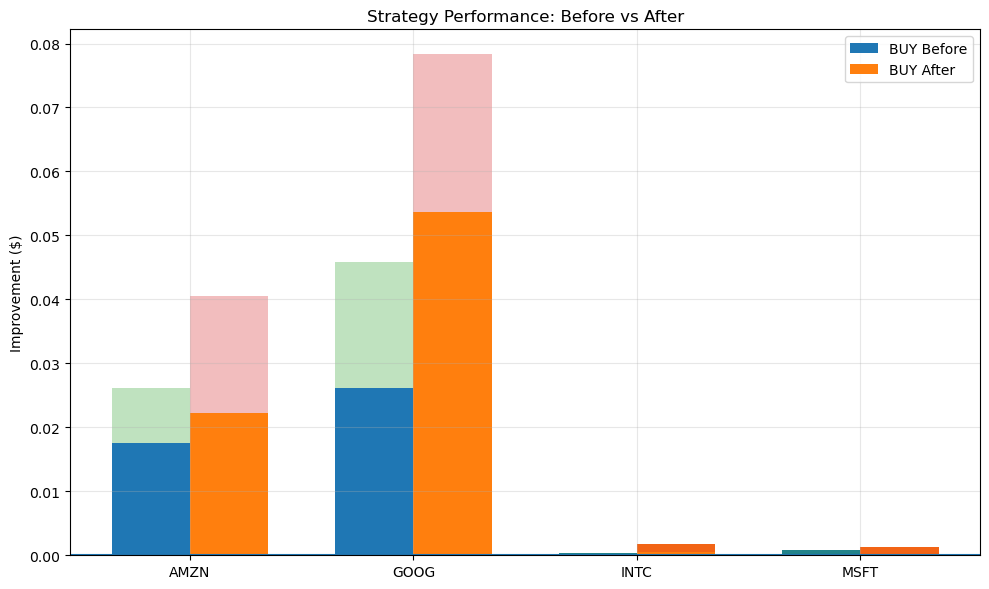

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 原始策略
# =========================
tickers = ["AMZN", "GOOG", "INTC", "MSFT"]

buy_before = [0.0176, 0.0261, 0.0004, 0.0008]
sell_before = [0.0085, 0.0197, -0.0004, -0.0006]

# =========================
# 改进策略
# =========================
buy_after = [0.0222, 0.0536, 0.0018, 0.0013]
sell_after = [0.0184, 0.0247, -0.0013, -0.0012]

# =========================
# 画图
# =========================
x = np.arange(len(tickers))
width = 0.35

plt.figure(figsize=(10,6))

# BUY
plt.bar(x - width/2, buy_before, width, label="BUY Before")
plt.bar(x + width/2, buy_after, width, label="BUY After")

# SELL（第二组）
plt.bar(x - width/2, sell_before, width, bottom=buy_before, alpha=0.3)
plt.bar(x + width/2, sell_after, width, bottom=buy_after, alpha=0.3)

# 轴
plt.xticks(x, tickers)
plt.ylabel("Improvement ($)")
plt.title("Strategy Performance: Before vs After")

# 参考线
plt.axhline(0)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()